In [1]:
# conda activate genomic_tools

import os
import sys
import pickle
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from collections import defaultdict

sys.path.append("code")

from modified_functions import *

In [25]:
def find_overlapping_cds(exon_start, exon_end, transcript_cds_rows):
    """Return the CDS row that overlaps this exon, or None."""
    for _, cds in transcript_cds_rows.iterrows():
        if cds['end'] >= exon_start and cds['start'] <= exon_end:
            return cds
    return None

def classify_overlap(exon_start, exon_end, cds_row):
    if cds_row['start'] == exon_start and cds_row['end'] == exon_end:
        return "fully_coding"
    elif cds_row['start'] >= exon_start and cds_row['end'] <= exon_end:
        return "partially_coding" # CDS subset of exon (should only happen when part of exon is UTR)
    else:
        return "unexpected"    # one side hangs over — rare
    
def _flanks_match(exons, es, ee, us_intron_start, ds_intron_end):
    left = [x for x in exons if x['end'] < es]
    right = [x for x in exons if x['start'] > ee]
    if not left or not right:
        return False                                  # terminal exon in this transcript
    left_exon = max(left, key=lambda x: x['end'])
    right_exon = min(right, key=lambda x: x['start'])
    return (left_exon['end'] + 1 == us_intron_start) and (right_exon['start'] - 1 == ds_intron_end)

def classify_isoform_detailed(exons, es, ee, us_intron_start, ds_intron_end, strand):
    """Returns (bucket, detail). detail carries the boundary sub-type for
    exon_diff_boundary, else None."""
    exact = overlap = None
    has_up = has_down = exonic_overlap = False
    for ex in exons:
        s, e = ex['start'], ex['end']
        if e < es:
            has_up = True
        if s > ee:
            has_down = True
        if s <= ee and e >= es:
            exonic_overlap = True
            if s == es and e == ee:
                exact = ex
            else:
                overlap = ex
    if exact is not None:
        bucket = ("compatible" if _flanks_match(exons, es, ee, us_intron_start, ds_intron_end)
                  else "exon_diff_junction")
        return bucket, None
    if overlap is not None:
        s, e = overlap['start'], overlap['end']
        if s == es:                                   # shares genomic-left boundary
            kind = "alt_5ss" if strand == '+' else "alt_3ss"
        elif e == ee:                                 # shares genomic-right boundary
            kind = "alt_3ss" if strand == '+' else "alt_5ss"
        else:
            kind = "overlapping_exon"
        return "exon_diff_boundary", {'start': s, 'end': e, 'kind': kind}
    if has_up and has_down and not exonic_overlap:
        return "exon_skipped", None
    return "locus_not_covered", None

def map_exon_to_protein(es, ee, cds_obj, strict=True):
    """Returns the CDS/aa annotation dict, or None if the transcript is
    noncoding or the exon falls in UTR. CDS rows MUST be in translation order."""
    cds = _cds_rows(cds_obj)
    if cds is None:
        return None                                   # noncoding transcript
    overlapping = next((c for c in cds if c['end'] >= es and c['start'] <= ee), None)
    if overlapping is None:
        return None                                   # exon is UTR here
    exon_cds_start, exon_cds_end = overlapping['start'], overlapping['end']
 
    cds_offset, gtf_frame = 0, None
    for c in cds:                                     # translation order
        if c['start'] == exon_cds_start and c['end'] == exon_cds_end:
            gtf_frame = c['frame']
            break
        cds_offset += c['end'] - c['start'] + 1
    rel_exon_start = cds_offset
    rel_exon_end = cds_offset + (exon_cds_end - exon_cds_start)
 
    first_frame = cds[0]['frame']                     # row 0 == translation-start CDS
    this_cds_frame = (first_frame - rel_exon_start) % 3
    if this_cds_frame != gtf_frame:
        msg = f"frame mismatch: computed {this_cds_frame}, GTF {gtf_frame} (check CDS ordering)"
        if strict:
            raise AssertionError(msg)
        return {'error': msg}
 
    coding_nt_length = exon_cds_end - exon_cds_start + 1
    overlap_type = ("fully_coding" if exon_cds_start == es and exon_cds_end == ee
                    else "partially_coding" if exon_cds_start >= es and exon_cds_end <= ee
                    else "unexpected")
    return {
        'aa_start': rel_exon_start // 3,
        'aa_end': rel_exon_end // 3,
        'coding_nt_length': coding_nt_length,
        'overlap_type': overlap_type,
        'gtf_frame': gtf_frame,
        'clean_start': gtf_frame == 0,
        'clean_end': (coding_nt_length - gtf_frame) % 3 == 0,
        'frame_preserving': coding_nt_length % 3 == 0,
        'exon_cds_start': exon_cds_start,
        'exon_cds_end': exon_cds_end
    }
 
def _exon_rows(obj):
    if obj is None:
        return []
    if hasattr(obj, "iterrows"):
        return [{'start': int(r['start']), 'end': int(r['end'])} for _, r in obj.iterrows()]
    return [{'start': int(e['start']), 'end': int(e['end'])} for e in obj]

def annotate_event(event, transcripts_by_gene, exons_by_transcript, cds_by_transcript,
                   strict=True):
    """event: {'chrom','strand','es','ee','gene','us_intron_start','ds_intron_end'}."""
    rec = {'meta': dict(event), 'cluster_id': None,
           'compatible': {}, 'exon_diff_junction': {},
           'exon_diff_boundary': {}, 'exon_skipped': {}, 'locus_not_covered': {}}
    es, ee = event['es'], event['ee']
    us, ds = event['us_intron_start'], event['ds_intron_end']
    
    for _, row in transcripts_by_gene.get(event['gene'], []).iterrows():
        t = row['transcript']
        ttype = row.get('transcript_type') 
        ttag = row.get('tag')
        exons = _exon_rows(exons_by_transcript.get(t))
        if not exons:
            continue
        
        bucket, detail = classify_isoform_detailed(exons, es, ee, us, ds, event['strand']) 
        if bucket in ("compatible", "exon_diff_junction"):
            mapped = map_exon_to_protein(es, ee, cds_by_transcript.get(t), strict=strict)
            entry = mapped if mapped is not None else {'overlap_type': 'noncoding_or_utr'}
        elif bucket == "exon_diff_boundary":
            entry = dict(detail)
        else:
            entry = {}
            
        entry['transcript_type'] = ttype
        entry['transcript_tag'] = ttag
        rec[bucket][t] = entry
        
    return rec

def _cds_rows(obj):
    if obj is None:
        return None
    if hasattr(obj, "iterrows"):
        return [{'start': int(r['start']), 'end': int(r['end']), 'frame': int(r['frame'])}
                for _, r in obj.iterrows()]
    return [{'start': int(c['start']), 'end': int(c['end']), 'frame': int(c['frame'])} for c in obj]

def cluster_events(events):
    """events: list of dicts with chrom,strand,es,ee; adds 'cluster_id' in place."""
    by_csg = defaultdict(list)
    for ev in events:
        by_csg[(ev['chrom'], ev['strand'], ev['gene'])].append(ev)
    cid = 0
    for grp in by_csg.values():
        grp.sort(key=lambda x: (x['es'], x['ee']))
        cur_end = None
        for ev in grp:
            if cur_end is None or ev['es'] > cur_end:
                cid += 1
                cur_end = ev['ee']
            else:
                cur_end = max(cur_end, ev['ee'])
            ev['cluster_id'] = cid
    return events

def mark_sibling_variants(event_info, event_coords):
    """For each exon_diff_boundary variant, flag whether its (start,end) matches
    a *called event* in the same cluster (i.e. the sibling was itself emitted)."""
    coords_by_cluster = defaultdict(set)
    for ev, cid in event_coords.items():
        coords_by_cluster[cid[0]].add((cid[1], cid[2]))   # cid = (cluster_id, es, ee)
        
    for rec in event_info.values():
        cid = rec['cluster_id']
        cluster = coords_by_cluster.get(cid, set())
        parent_es = rec['meta']['es']
        parent_ee = rec['meta']['ee']
        
        for t, sib in rec['exon_diff_boundary'].items():
            sib_es, sib_ee = sib['start'], sib['end']
            sib['is_called_sibling'] = (
                (sib_es, sib_ee) in cluster                        # called event
                and (sib_es == parent_es or sib_ee == parent_ee)   # shares a boundary
            )

    return event_info

In [3]:
# Get all significant splicing events
signif_info = defaultdict(dict)
for file in os.listdir("data/ctype_exons"):
    if file.endswith("exons.csv"):
        signif_exons_df = pd.read_csv(f"data/ctype_exons/{file}", index_col=0)
        ct = file.replace("_exons.csv", "")
        for idx, row in signif_exons_df.iterrows():
            signif_info[idx]['gene_name'] = row['Gene']   # store once at event level
            signif_info[idx][ct] = {'is_specific': row['is_specific'], 'r': row['r'], 'fdr': row['fdr']}

In [19]:
# Load GTF

exclude = ""
gene_name = "gene_id"
gene_type = "all"
no_trim_id = False
gene_type_tag = "gene_type"
transcript_type_tag = "transcript_type"

gtf_file = "/mnt/lareaulab/reliscu/data/GENCODE/GRCh38/gencode.v46.annotation.gtf"
gtf = process_gtf(gtf_file, exclude, gene_name, no_trim_id, gene_type_tag, transcript_type_tag)

gtf_exon = gtf[gtf.feature == "exon"]
gtf_indexed = gtf_exon.set_index(['chrom', 'start', 'end']).sort_index() # for exon lookup
exons_by_transcript = {t: grp for t, grp in gtf_exon.groupby('transcript')}  # for transcript lookup

gtf_cds = gtf[gtf.feature == "CDS"]
cds_by_transcript = {t: grp for t, grp in gtf_cds.groupby('transcript')}  # for transcript lookup for coding sequences

gtf_transcript = gtf[gtf.feature == "transcript"]
transcripts_by_gene = {t: grp for t, grp in gtf_transcript.groupby('gene')}  # for transcript lookup for coding sequences

Processing GTF file...


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_type', 'gene_name', 'level', 'tag', 'transcript_id', 'transcript_type', 'transcript_name', 'transcript_support_level', 'havana_transcript', 'exon_number', 'exon_id', 'hgnc_id', 'havana_gene', 'ont', 'protein_id', 'ccdsid', 'artif_dupl']


In [ ]:
# Load intron table (with jxn coordinates per event)
intron_file = "/mnt/lareaulab/reliscu/data/GENCODE/GRCh38/psix_annotation/intron_file.tab.gz"
intron_table = pd.read_csv(intron_file, sep='\t', index_col=0)

all_jxns_df = intron_table.copy()
all_jxns_df[['strand', 'chr']] = all_jxns_df['intron'].str.split(":", expand=True).iloc[:, [2, 0]]
coords = all_jxns_df['intron'].str.split(':').str[1].str.split('-')
all_jxns_df['intron_start'] = coords.str[0].astype(int)
all_jxns_df['intron_end'] = coords.str[1].astype(int)

# Get all splicing events detected
detected_events_df = pd.read_csv("data/ctype_exons/exon_PSI_abundance_correlations.csv", index_col=0)

# Subset jxn table to these events
event_jxns_df = all_jxns_df[all_jxns_df['event'].isin(detected_events_df.index)]
event_jxns_df.shape

# Add exon boundary coords

def safe_exon_coords(g):
    i1 = g.loc[g.index.str.contains("I1$")]
    i2 = g.loc[g.index.str.contains("I2$")]
    if len(i1) == 0 or len(i2) == 0:
        return pd.Series({"exon_start": None, "exon_end": None})
    
    return pd.Series({
        "exon_start": i1["intron_end"].values[0] + 1,
        "exon_end": i2["intron_start"].values[0] - 1
    })
 
exon_coords_df = event_jxns_df.groupby("event").apply(safe_exon_coords)

event_df = event_jxns_df.merge(exon_coords_df, on="event").drop(columns="intron")
event_df.set_index("event", drop=True, inplace=True) 

event_lookup = {}
for idx, row in event_df.iterrows():
    if idx not in event_lookup:  # skip if already seen
        event_lookup[idx] = {
            "gene": row['gene'],
            "chr": row['chr'],
            "exon_start": row['exon_start'],
            "exon_end": row['exon_end']
        }

In [8]:
len(event_lookup)

47058

In [10]:
event_jxns_df.head()

,intron,event,gene,strand,chr,intron_start,intron_end
ENSG00000292994_other_1_I1,chr1:259026-261549:-,ENSG00000292994_other_1,ENSG00000292994,-,chr1,259026,261549
ENSG00000292994_other_1_I2,chr1:261635-267302:-,ENSG00000292994_other_1,ENSG00000292994,-,chr1,261635,267302
ENSG00000292994_other_1_SE,chr1:259026-267302:-,ENSG00000292994_other_1,ENSG00000292994,-,chr1,259026,267302
ENSG00000290385_other_1_I1,chr1:497300-498046:-,ENSG00000290385_other_1,ENSG00000290385,-,chr1,497300,498046
ENSG00000290385_other_1_I2,chr1:498306-498398:-,ENSG00000290385_other_1,ENSG00000290385,-,chr1,498306,498398


# For each event: catalogue all transcript scenarios (same jxns, exon skipped, same exon but different jxns, one shared jxn, etc.)
### Will need this info later to interpret functional consequence of a given splicing event

In [ ]:
# note: this takes ~15 minutes

event_info = {}
event_dicts = []
for idx, val in event_lookup.items():
    rows = event_jxns_df[event_jxns_df.event == idx]
    i1 = rows[rows.index.str.endswith("I1")]
    i2 = rows[rows.index.str.endswith("I2")]
    strand = gtf_indexed.loc[(val['chr'], val['exon_start'], val['exon_end'])].strand.values[0]
    event = {
        'chrom': val['chr'], 
        'strand': strand,
        'es': int(val['exon_start']), 
        'ee': int(val['exon_end']),
        'gene': val['gene'], 
        'us_intron_start': int(i1.intron_start.values[0]),
        'ds_intron_end':  int(i2.intron_end.values[0]),
    }
    event_info[idx] = annotate_event(event, transcripts_by_gene, exons_by_transcript, cds_by_transcript)
    event_dicts.append({'event': idx, **{k: event[k] for k in ('gene','chrom','strand','es','ee')}})

In [ ]:
# group events that share junctions
cluster_events(event_dicts) 

# add this info to event_info
for ed in event_dicts:
    event_info[ed['event']]['cluster_id'] = ed['cluster_id']
    
# within a cluster, log events that were actually detected as "sibling" events
event_coords = {ed['event']: (ed['cluster_id'], ed['es'], ed['ee']) for ed in event_dicts}

event_info = mark_sibling_variants(event_info, event_coords)

In [ ]:
for ev, rec in event_info.items():
    if ev in signif_info:
        rec['cell_type_specific'] = True
    else:
        rec['cell_type_specific'] = False

In [ ]:
pickle.dump(event_dicts, open('event_dicts.pkl', 'wb'))
pickle.dump(event_info, open('event_info.pkl', 'wb'))

In [ ]:
event_dicts = pickle.load(open('event_dicts.pkl', 'rb'))
event_info = pickle.load(open('event_info.pkl', 'rb'))

In [11]:
from collections import defaultdict
members = defaultdict(list)
for ed in event_dicts:
    members[ed['cluster_id']].append(ed['event'])
    
from collections import Counter
sizes = Counter(ed['cluster_id'] for ed in event_dicts)

specific_cids = [
    cid for cid, evs in members.items()
    if any(
        any(info['is_specific'] for info in signif_info.get(ev, {}).values()
            if isinstance(info, dict))
        for ev in evs
    )
]

multi = {cid: n for cid, n in sizes.items() if (n > 1) and cid in specific_cids}
sorted_cids = [cid for cid, n in sorted(multi.items(), key=lambda kv: -kv[1])]

In [ ]:
# """
# plot_clusters.py

# Genome-browser-style visualization of one splicing cluster.
# Left panel  : exon/intron structure per event.
# Right panel : per-cell-type r-value heatmap (from signif_info).

# Usage
# -----
# from plot_clusters import plot_cluster

# plot_cluster(cid, members[cid], event_info, signif_info)
# plot_cluster(cid, members[cid], event_info, signif_info, save_path='cluster_5178.pdf')

# signif_info format
# ------------------
# signif_info[event_id]['gene_name'] = str                                  # store once per event
# signif_info[event_id][cell_type]   = {'r': float, 'fdr': float, 'is_specific': bool}

# Build it like this:
#     for idx, row in signif_exons_df.iterrows():
#         signif_info[idx]['gene_name'] = row['Gene']
#         signif_info[idx][ct] = {'is_specific': row['is_specific'],
#                                  'r': row['r'], 'fdr': row['fdr']}
# """
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# from matplotlib.patches import Rectangle
# from matplotlib.colors import TwoSlopeNorm


# # ── shared row builder (both panels use the same sorted order) ─────────────
# def _build_rows(event_ids, event_info, signif_set):
#     rows = []
#     for ev in event_ids:
#         if ev not in event_info:
#             continue
#         meta = event_info[ev]['meta']
#         rows.append({
#             'event': ev,
#             'chrom': meta['chrom'],
#             'gene':  meta.get('gene', ''),
#             'es':    meta['es'],
#             'ee':    meta['ee'],
#             'us':    meta['us_intron_start'],
#             'ds':    meta['ds_intron_end'],
#             'signif': ev in signif_set,
#         })
#     rows.sort(key=lambda r: (r['es'], r['ee'], r['ds']))
#     return rows


# # ── left panel: exon / intron structure ───────────────────────────────────
# def _plot_structure(ax, cid, rows, signif_set, signif_info):
#     if not rows:
#         ax.set_visible(False)
#         return

#     x_min = min(r['us'] for r in rows)
#     x_max = max(r['ds'] for r in rows)
#     span  = max(x_max - x_min, 1)
#     pad   = span * 0.04

#     for i, r in enumerate(rows):
#         color = 'tomato' if r['signif'] else 'steelblue'

#         # intron span line
#         ax.plot([r['us'], r['ds']], [i, i],
#                 color='#bbbbbb', lw=0.8, zorder=1, solid_capstyle='round')

#         # cassette exon block
#         width = max(r['ee'] - r['es'], span * 0.003)
#         ax.add_patch(Rectangle((r['es'], i - 0.3), width, 0.6,
#                                 facecolor=color, edgecolor='none', zorder=2))

#         # event label
#         parts  = r['event'].split('_')
#         label  = '_'.join(parts[-2:]) if len(parts) >= 2 else r['event']
#         marker = ' ★' if r['signif'] else ''
#         ax.text(x_min - pad, i, label + marker,
#                 ha='right', va='center', fontsize=5.5,
#                 color='tomato' if r['signif'] else '#555555')

#     # gene display name: scan all rows for first event that has gene_name in signif_info
#     gene_display = next(
#         (signif_info[r['event']].get('gene_name')
#         for r in rows
#         if r['event'] in signif_info and signif_info[r['event']].get('gene_name')),
#         rows[0]['gene']
#     )
#     n_sig = sum(r['signif'] for r in rows)
#     ax.set_title(
#         f"cluster {cid}  |  {gene_display}  |  {rows[0]['chrom']}\n"
#         f"{len(rows)} events  ({n_sig} significant in ≥1 cell type)",
#         fontsize=6.5, loc='left', pad=3
#     )
#     ax.set_xlim(x_min - pad * 2, x_max + pad)
#     ax.set_ylim(-0.8, len(rows) - 0.2)
#     ax.set_yticks([])

#     def _kb(x, _):
#         return f'+{(x - x_min) / 1000:.1f}kb' if x != x_min else '0'
#     ax.xaxis.set_major_formatter(plt.FuncFormatter(_kb))
#     ax.xaxis.set_major_locator(plt.MaxNLocator(4, integer=False))
#     ax.tick_params(axis='x', labelsize=5.5, pad=1)
#     for spine in ('top', 'left', 'right'):
#         ax.spines[spine].set_visible(False)
#     ax.spines['bottom'].set_linewidth(0.5)


# # ── right panel: per-cell-type r-value heatmap ────────────────────────────
# def _plot_celltype_panel(ax, rows, signif_info, cell_types):
#     norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
#     cmap = plt.get_cmap('RdBu_r')

#     for i, r in enumerate(rows):
#         ev = r['event']
#         for j, ct in enumerate(cell_types):
#             info = signif_info.get(ev, {}).get(ct)
#             if isinstance(info, dict):
#                 color = cmap(norm(float(np.clip(info['r'], -1, 1))))
#                 ec = 'black' if info.get('is_specific') else 'white'
#                 lw = 1.2    if info.get('is_specific') else 0.3
#             else:
#                 color, ec, lw = '#eeeeee', 'white', 0.3

#             ax.add_patch(Rectangle((j, i - 0.4), 1, 0.8,
#                                     facecolor=color, edgecolor=ec,
#                                     linewidth=lw, zorder=2))

#             # dot for FDR < 0.01
#             if isinstance(info, dict) and info.get('fdr', 1) < 0.01:
#                 ax.text(j + 0.5, i, '·', ha='center', va='center',
#                         fontsize=9, color='white', zorder=3)

#     ax.set_xlim(0, len(cell_types))
#     ax.set_ylim(-0.8, len(rows) - 0.2)
#     ax.set_xticks([j + 0.5 for j in range(len(cell_types))])
#     ax.set_xticklabels(cell_types, rotation=40, ha='left', fontsize=5.5)
#     ax.xaxis.set_tick_params(length=0)
#     ax.tick_params(axis='x', pad=1)
#     ax.set_yticks([])
#     for spine in ax.spines.values():
#         spine.set_visible(False)

#     # colorbar
#     sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
#     sm.set_array([])
#     cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02, aspect=12)
#     cbar.set_label('r', fontsize=6)
#     cbar.ax.tick_params(labelsize=5)
#     cbar.set_ticks([-1, -0.5, 0, 0.5, 1])


# # ── main entry point ───────────────────────────────────────────────────────
# def plot_cluster(cid, event_ids, event_info, signif_info,
#                  figsize=None, save_path=None, dpi=150):
#     """
#     Parameters
#     ----------
#     cid           : cluster id (for the title)
#     event_ids     : members[cid]
#     event_info     : dict  event_id -> annotate_event record
#     signif_info   : dict  event_id -> {'gene_name': str, cell_type: {'r','fdr','is_specific'}}
#     figsize       : (width, height) in inches; None = auto
#     save_path     : file path to save (e.g. 'cluster.pdf'); None = plt.show()
#     dpi           : resolution for raster output
#     """
#     signif_set = set(signif_info.keys())
#     rows       = _build_rows(event_ids, event_info, signif_set)

#     if not rows:
#         print(f"cluster {cid}: no events found in event_info")
#         return None

#     # cell types: all keys except 'gene_name', skip non-dict values defensively
#     cell_types = sorted({
#         ct
#         for r in rows
#         for ct, val in signif_info.get(r['event'], {}).items()
#         if ct != 'gene_name' and isinstance(val, dict)
#     })

#     n      = len(rows)
#     height = max(1.8, n * 0.38)

#     if cell_types:
#         n_ct         = len(cell_types)
#         default_size = (7 + n_ct * 0.7, height)
#         fig, (ax_l, ax_r) = plt.subplots(
#             1, 2,
#             figsize=figsize or default_size,
#             gridspec_kw={'width_ratios': [4, max(1, n_ct)]}
#         )
#         _plot_celltype_panel(ax_r, rows, signif_info, cell_types)
#         ax_r.set_title('cell-type associations\n(border = specific, · = FDR<0.01)',
#                         fontsize=6, loc='left', pad=3)
#     else:
#         fig, ax_l = plt.subplots(figsize=figsize or (7, height))

#     _plot_structure(ax_l, cid, rows, signif_set, signif_info)

#     ax_l.legend(handles=[
#         mpatches.Patch(facecolor='tomato',    label='significant (any ct)'),
#         mpatches.Patch(facecolor='steelblue', label='not significant'),
#     ], loc='upper right', fontsize=5.5, frameon=False)

#     plt.tight_layout(pad=1.5)

#     if save_path:
#         fig.savefig(save_path, dpi=dpi, bbox_inches='tight')
#         print(f"saved -> {save_path}")
#     else:
#         plt.show()

#     return fig

5178


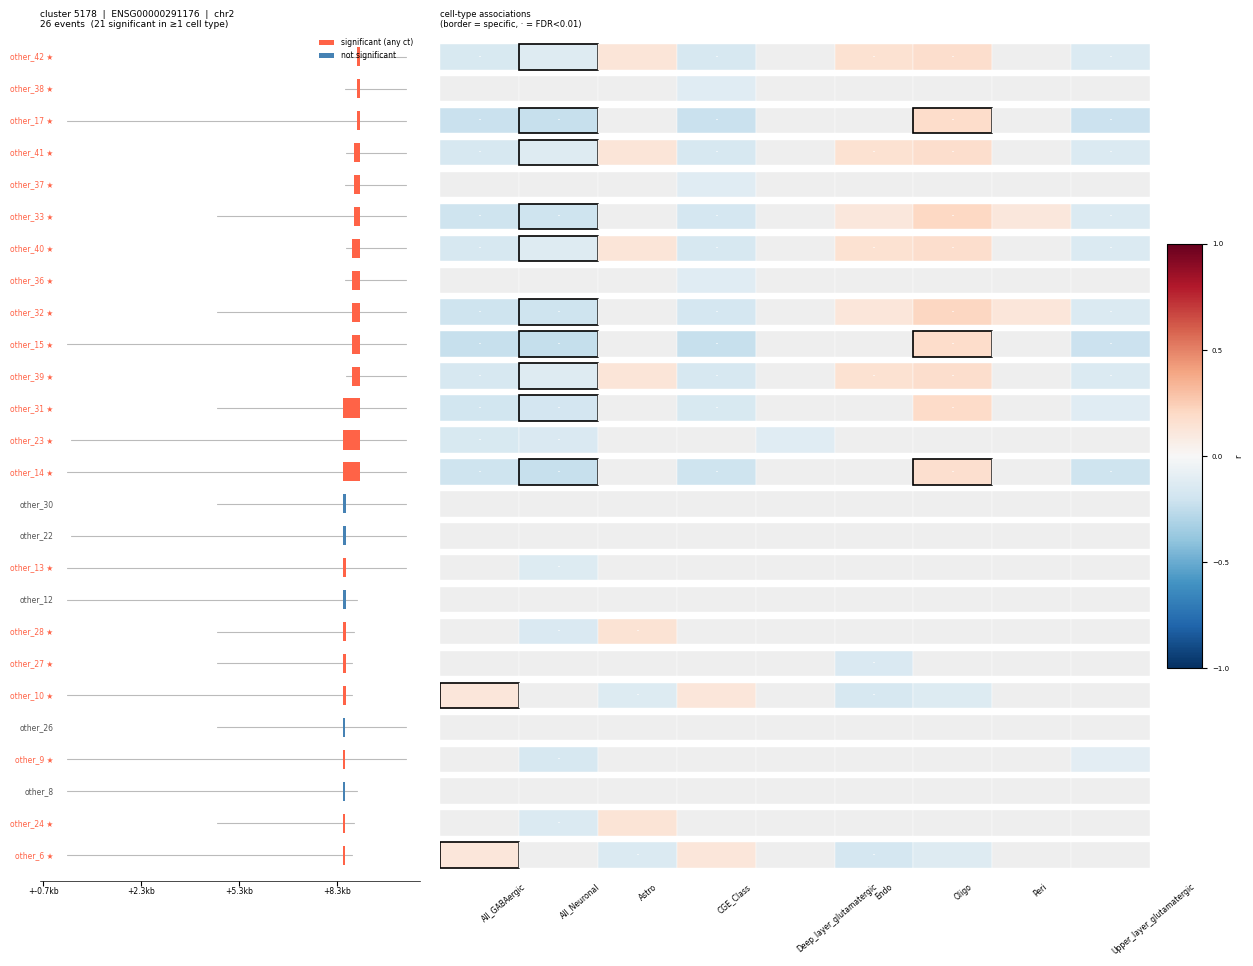

33741


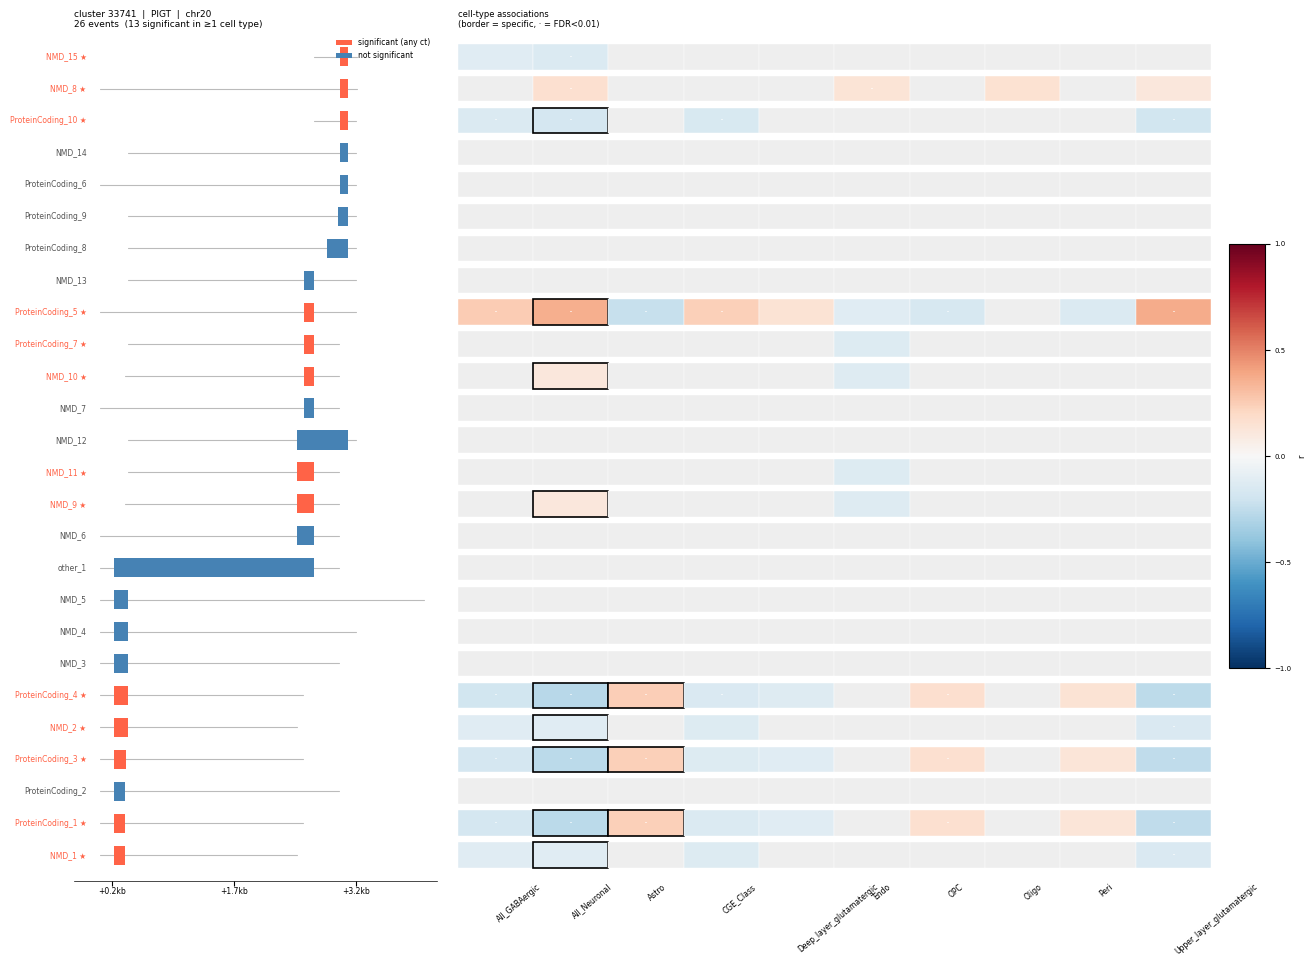

15758


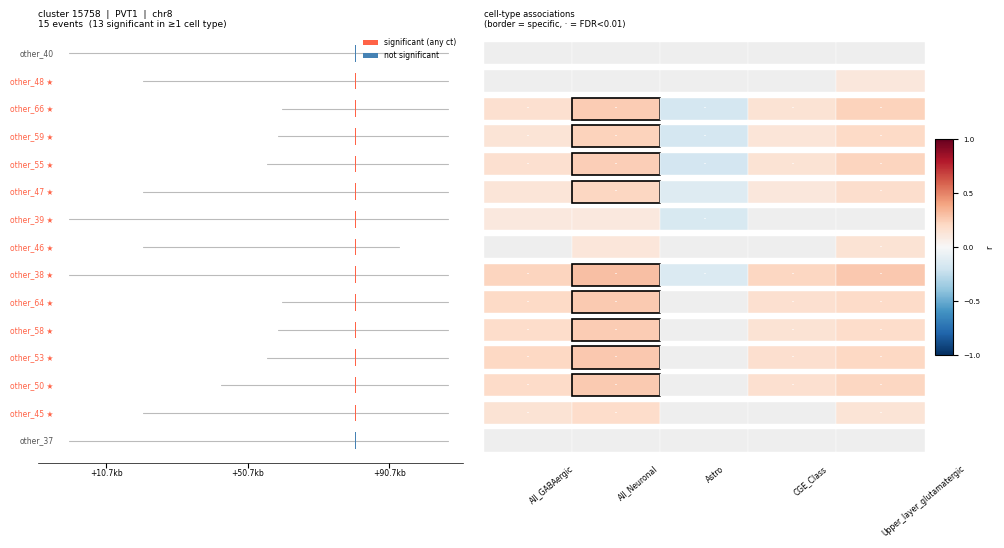

1105


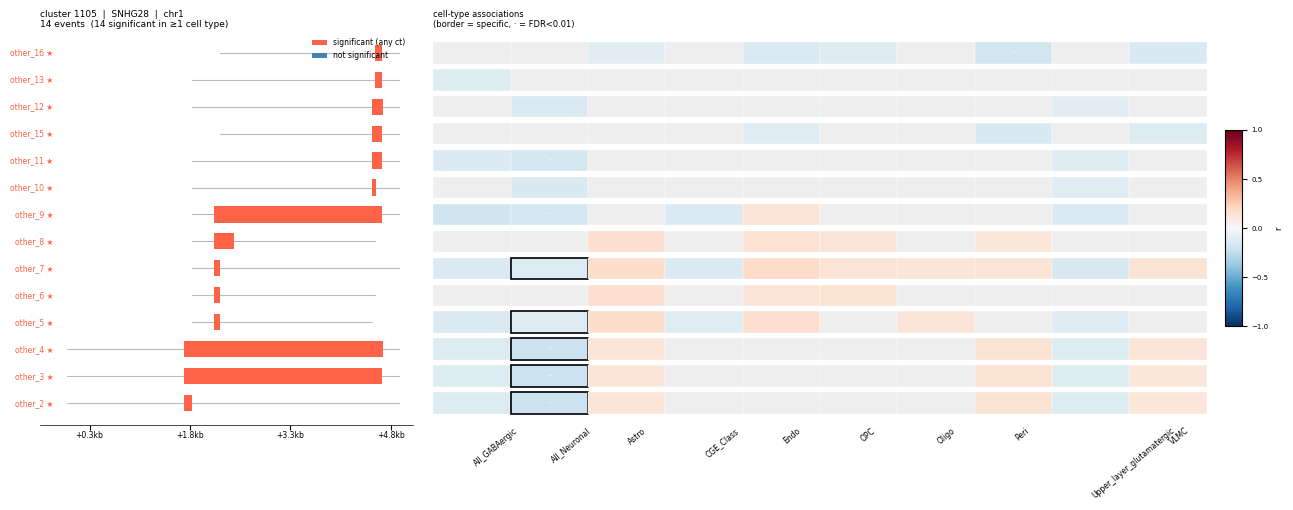

14615


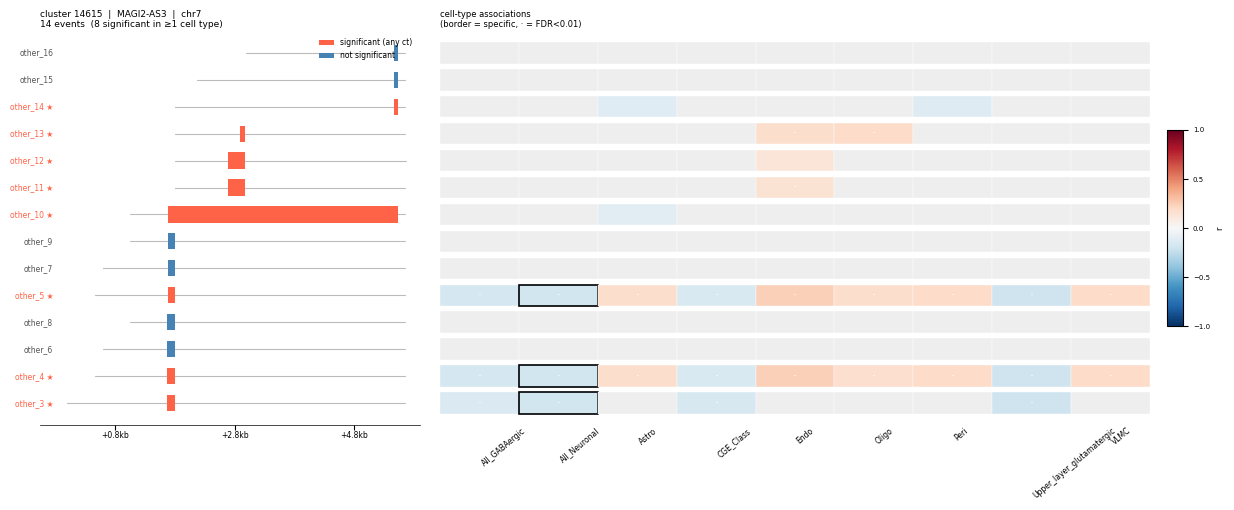

27642


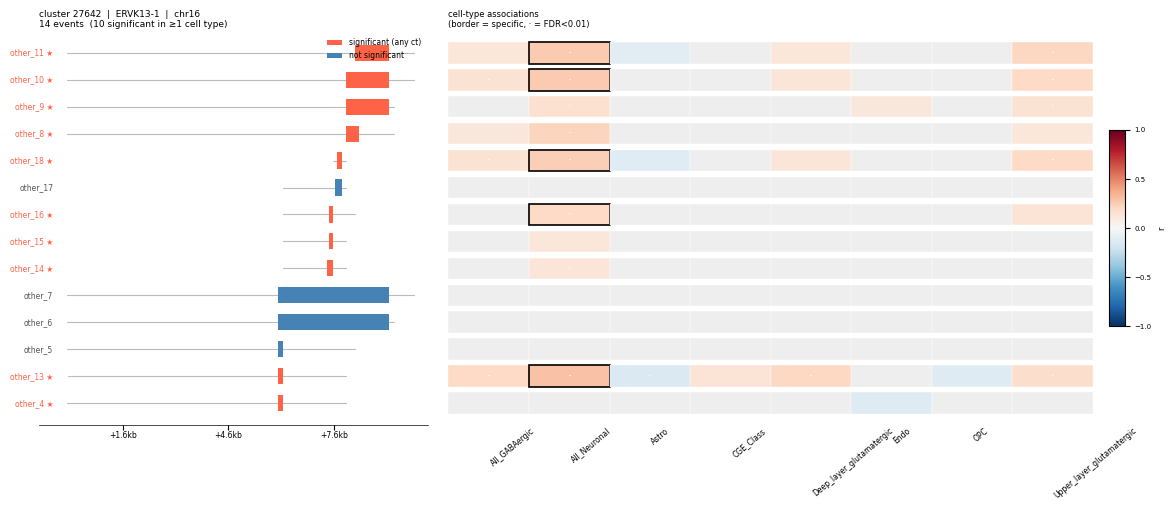

773


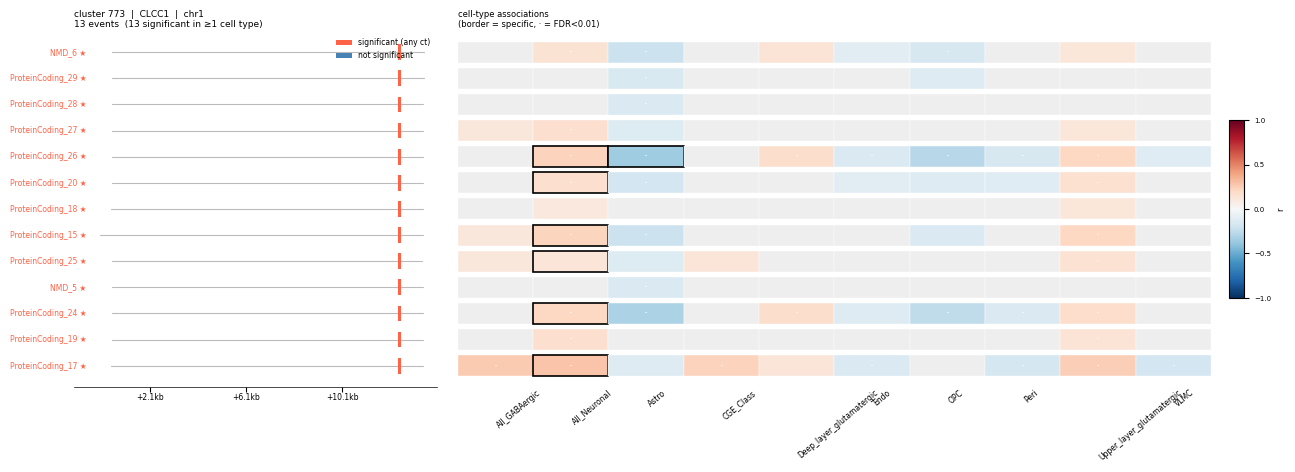

4113


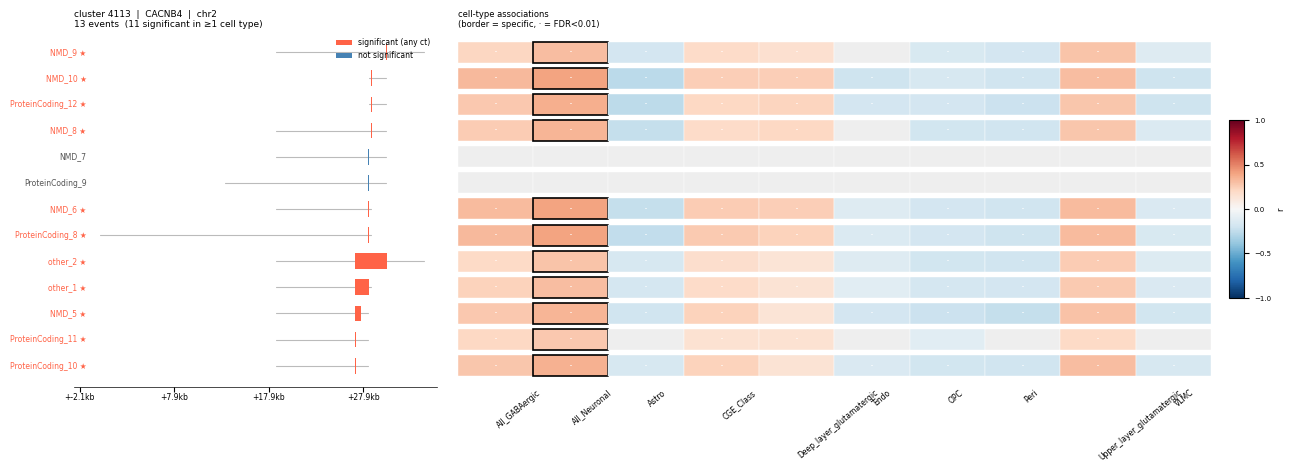

20188


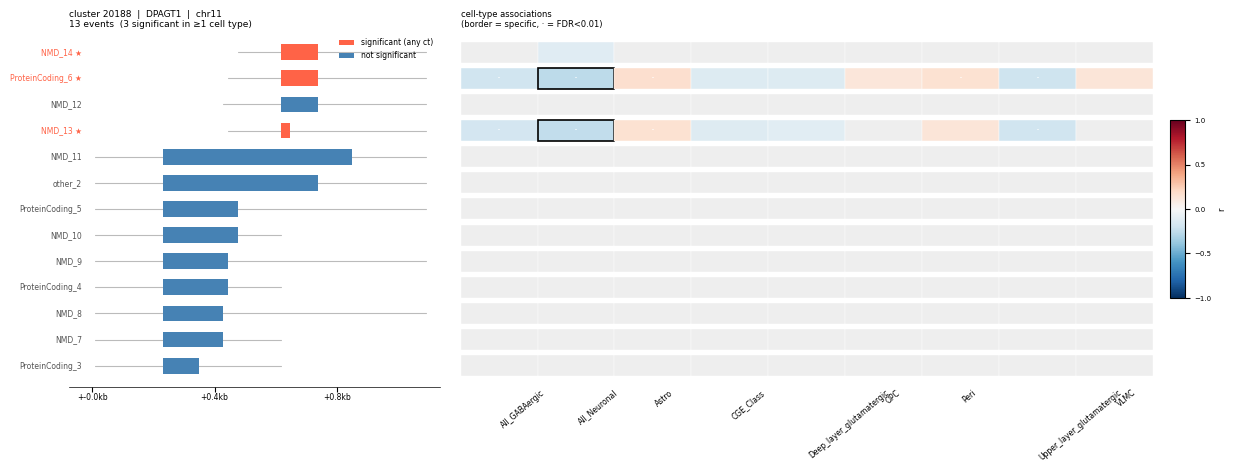

21754


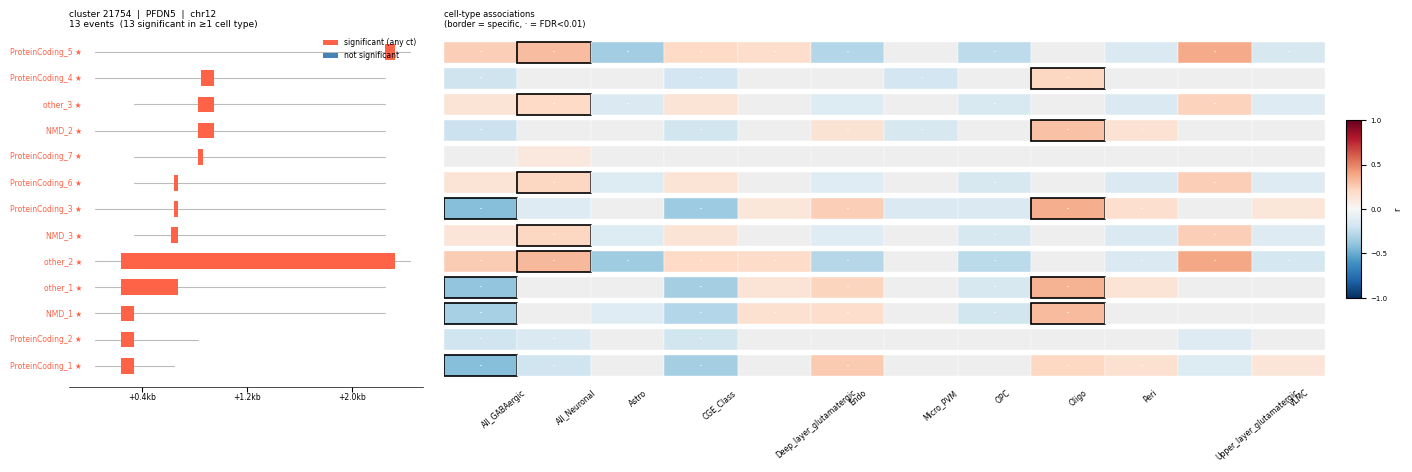

29460


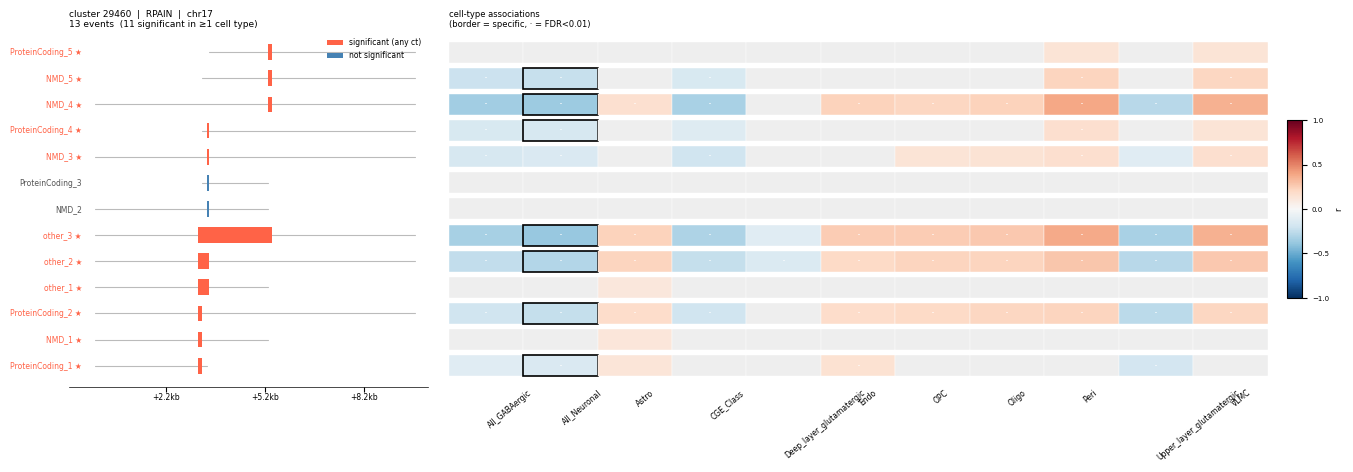

29570


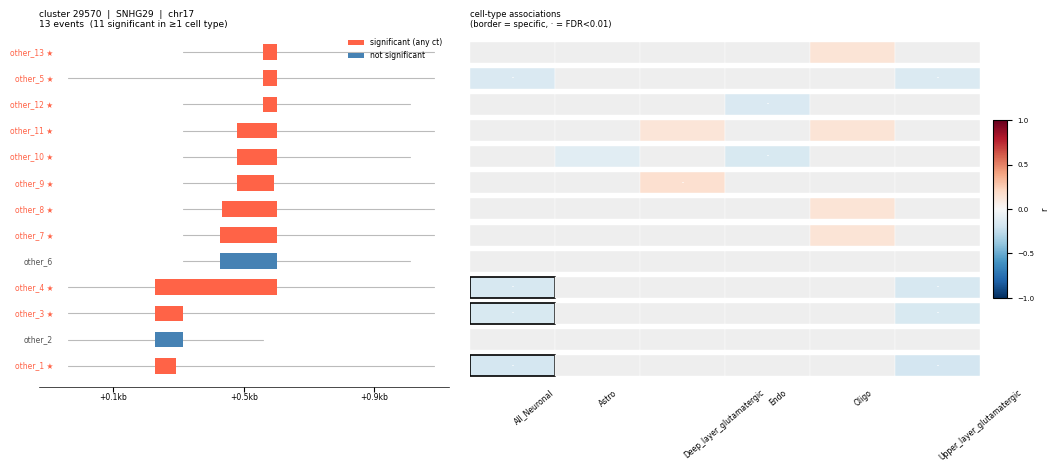

35322


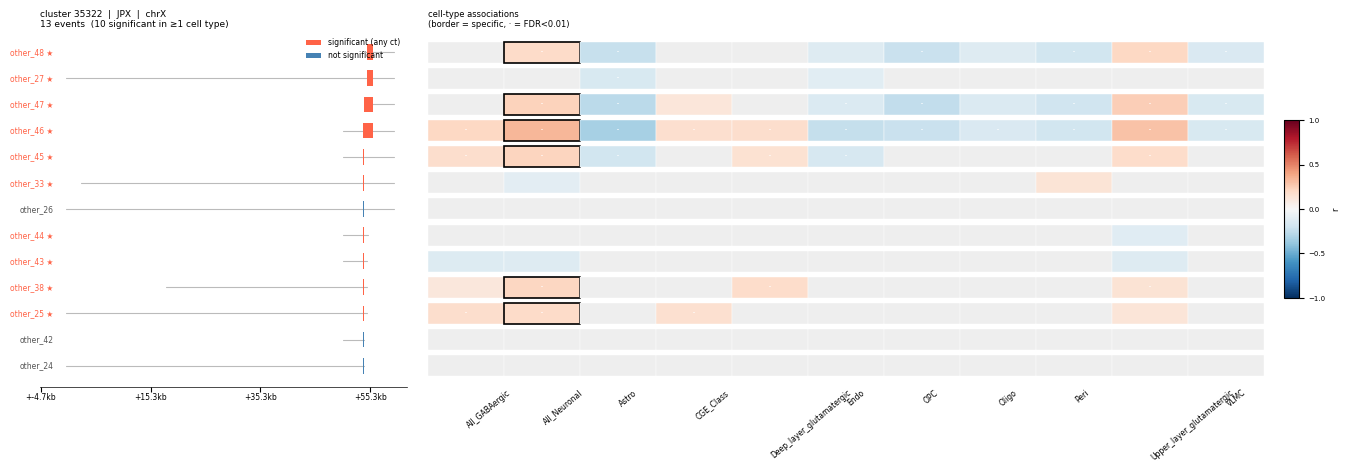

1200


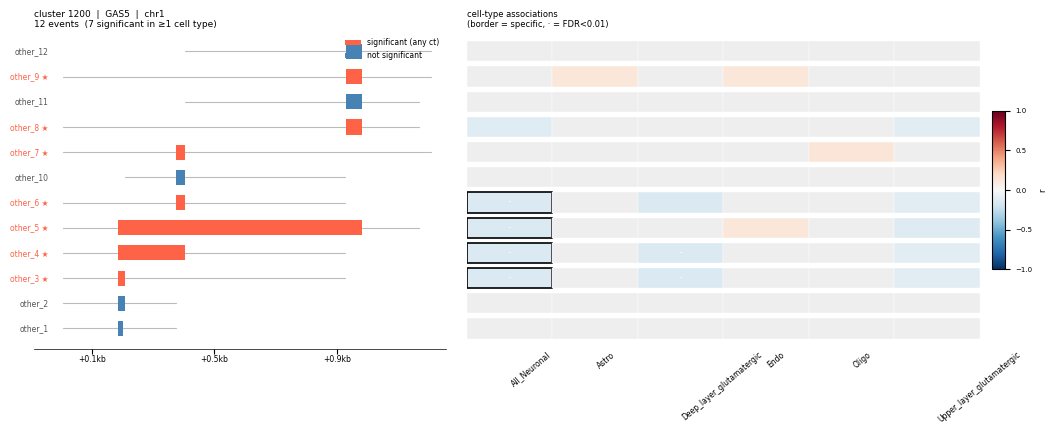

1441


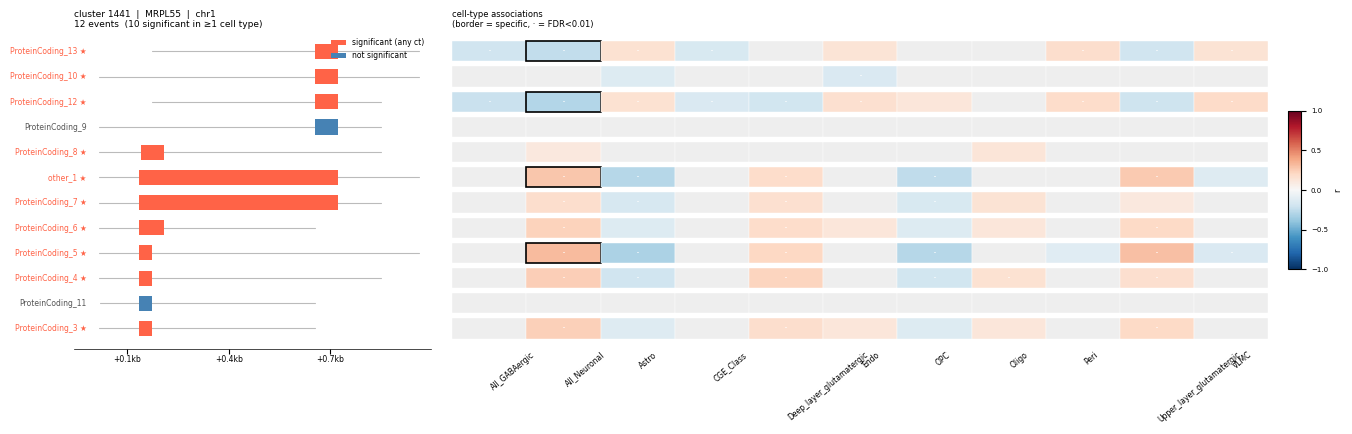

13232


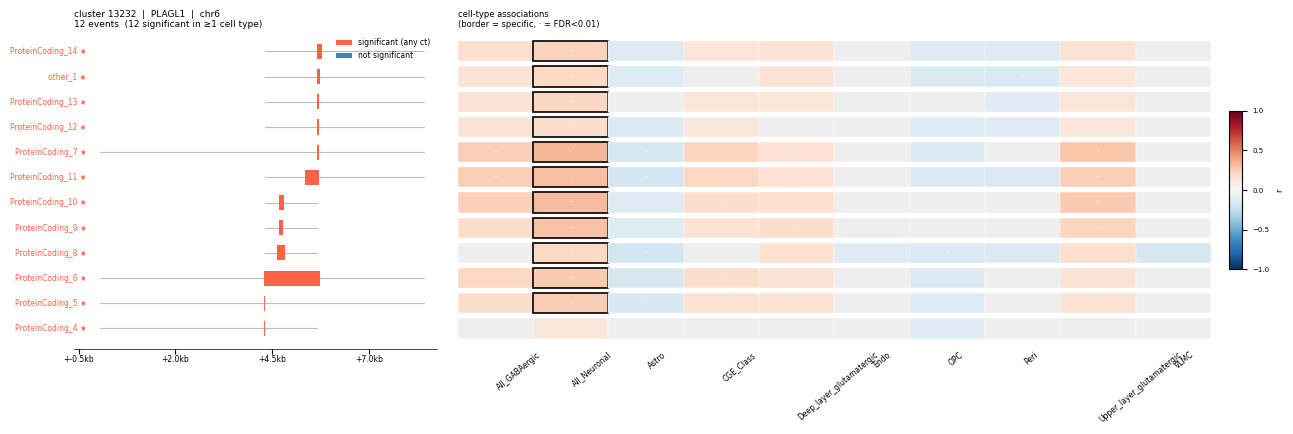

33273


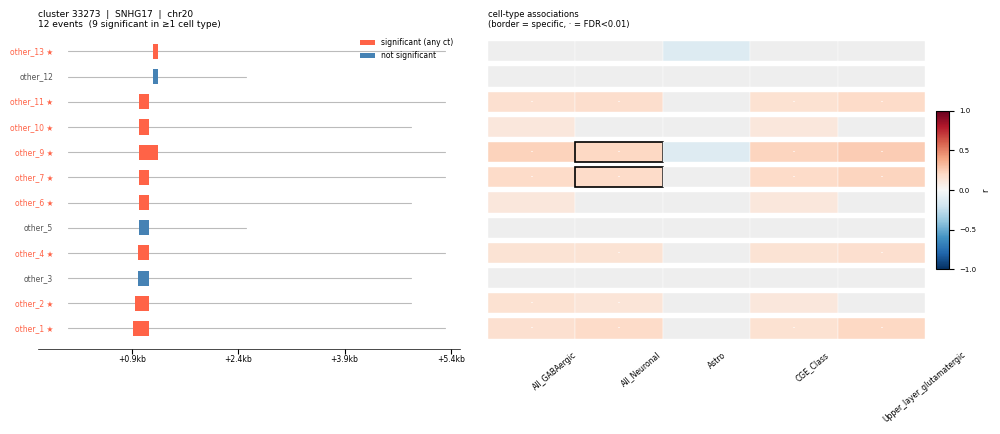

35320


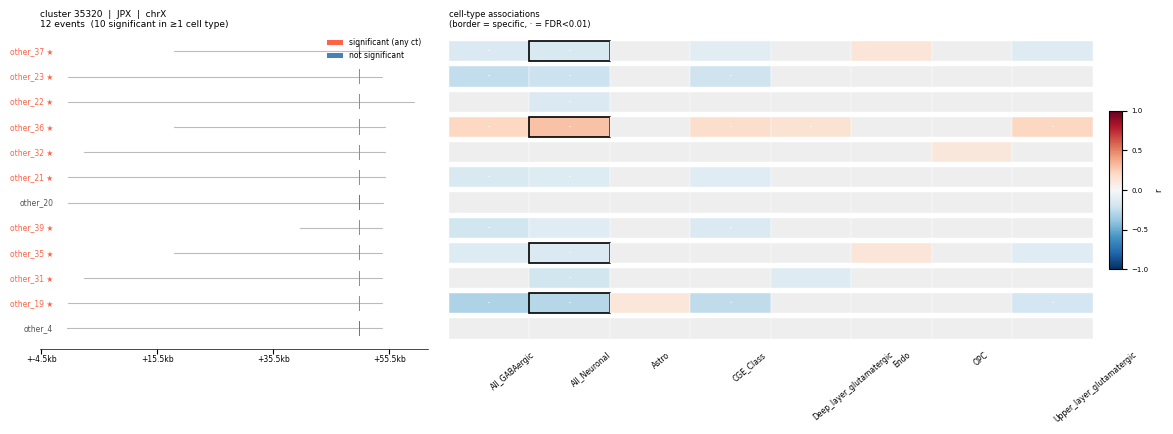

3240


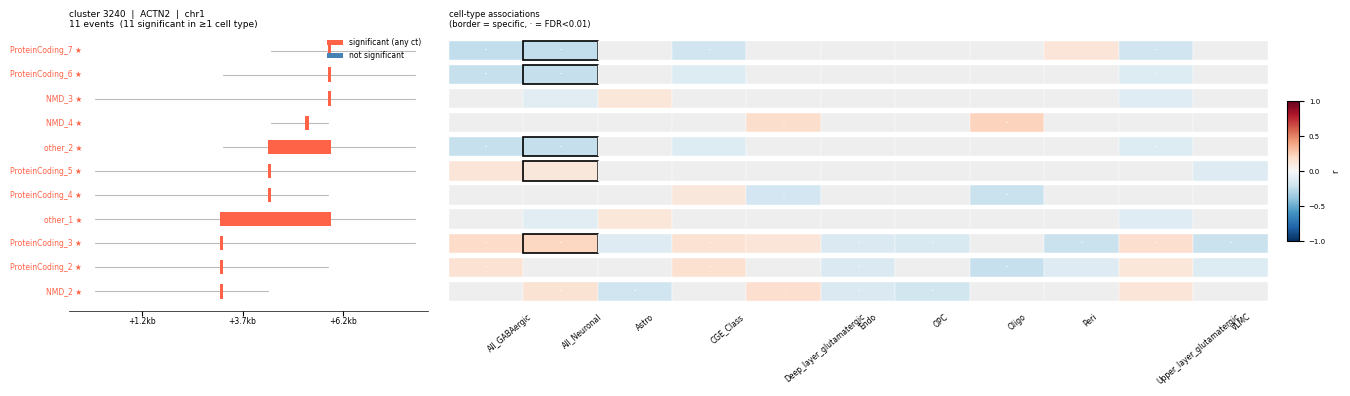

7943


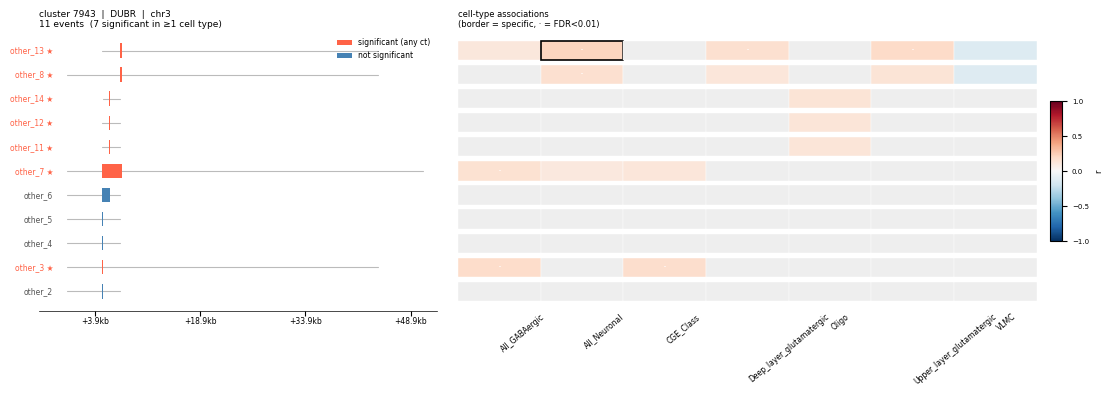

13245


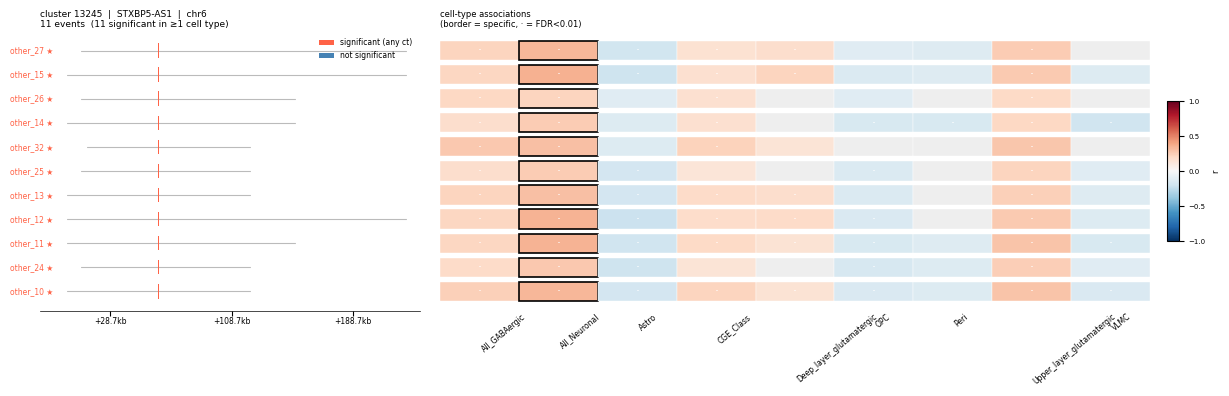

15879


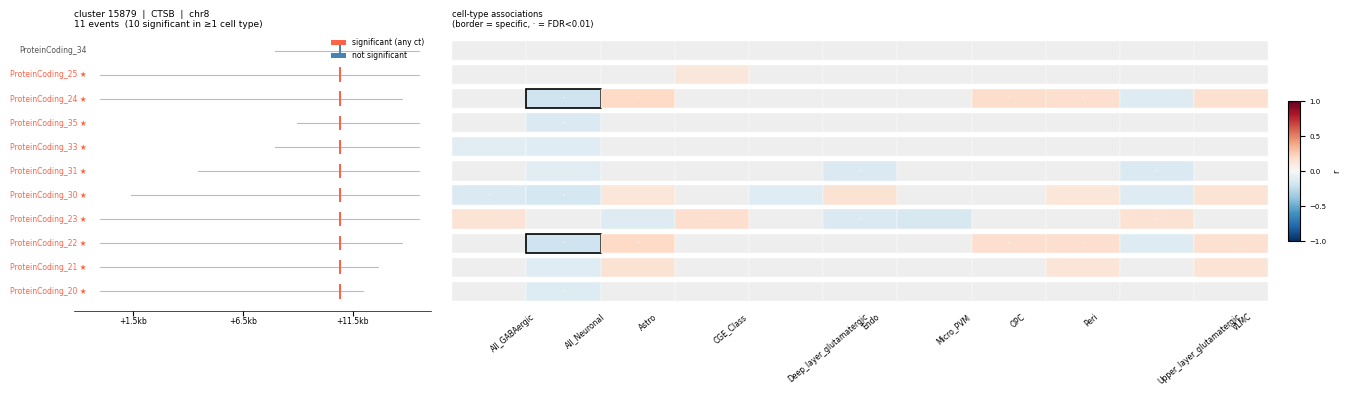

25349


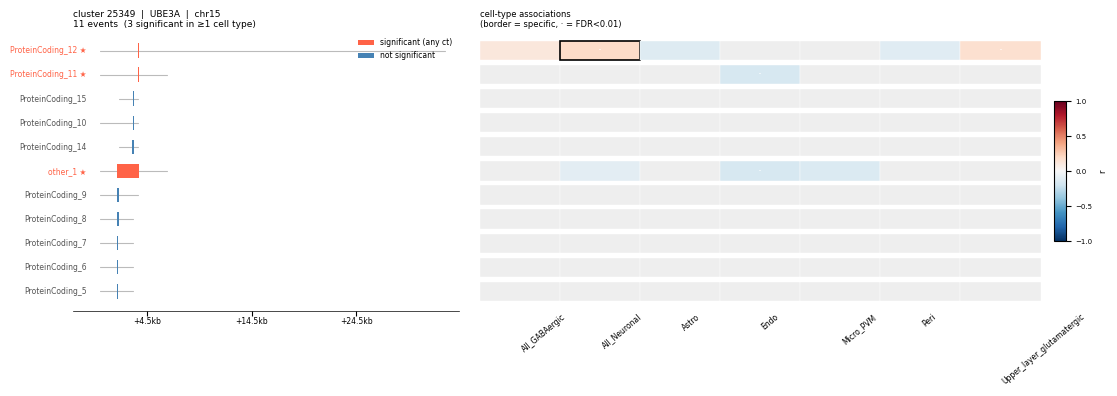

32676


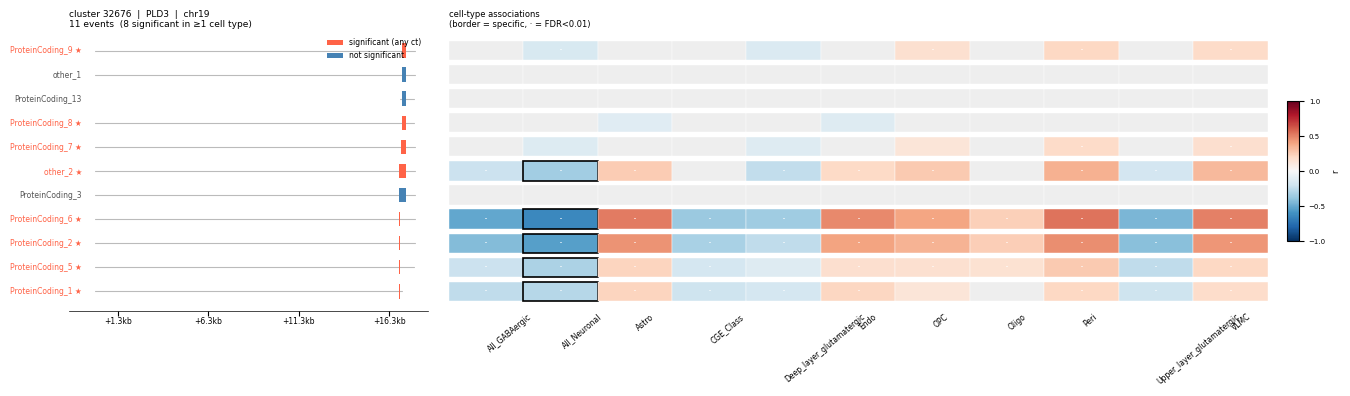

1896


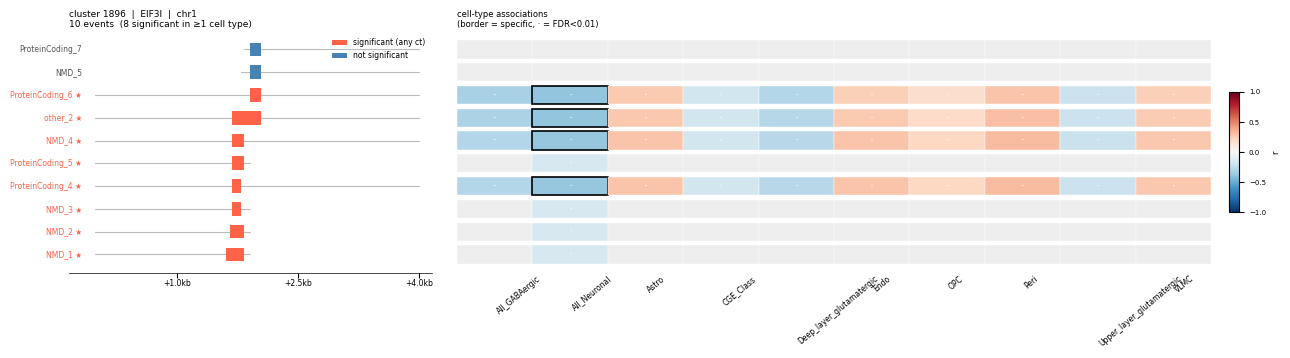

17128


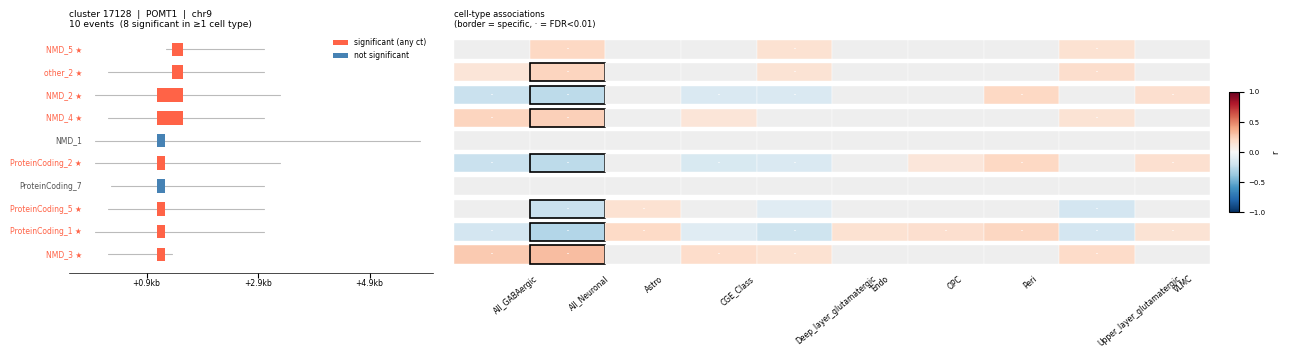

20036


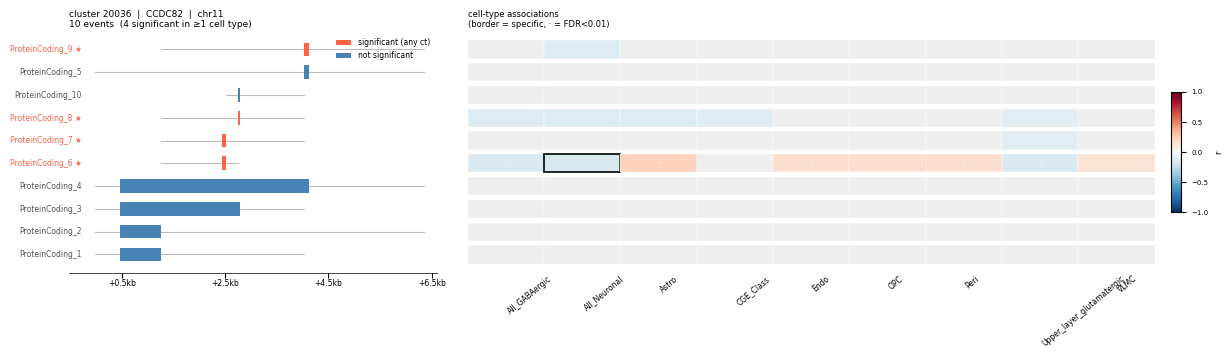

24776


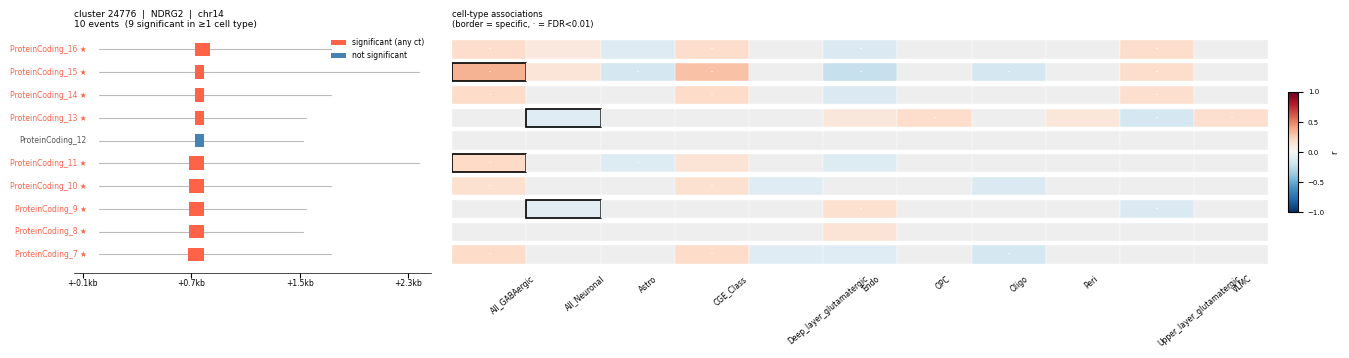

3742


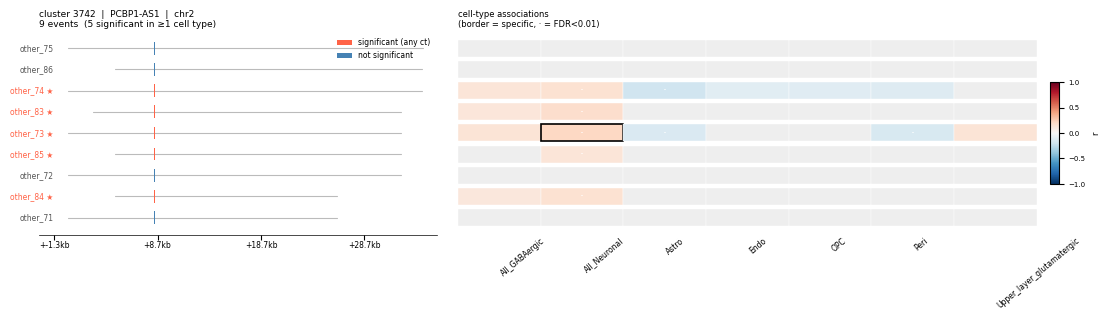

6602


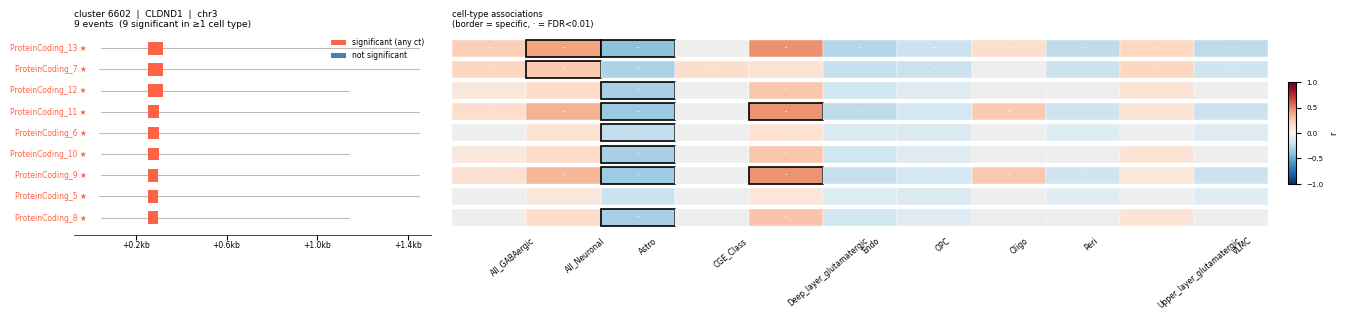

8575


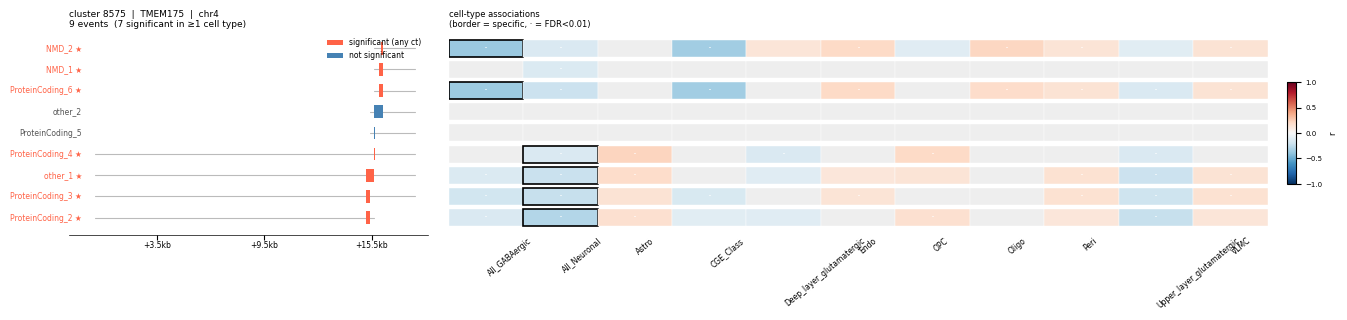

12681


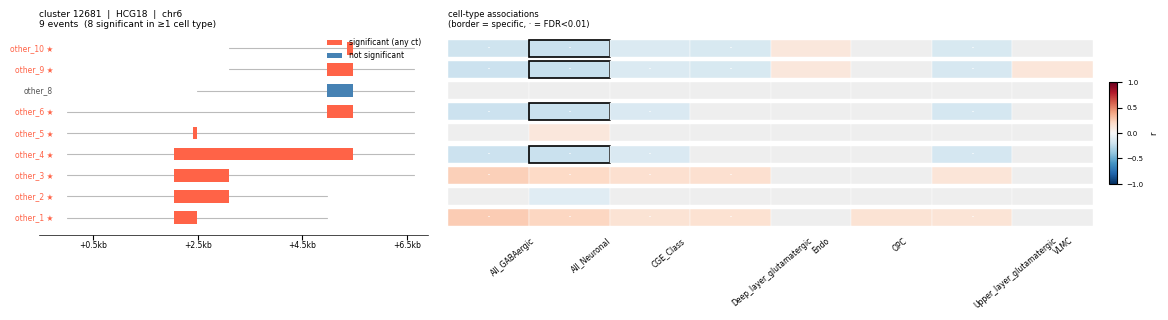

18638


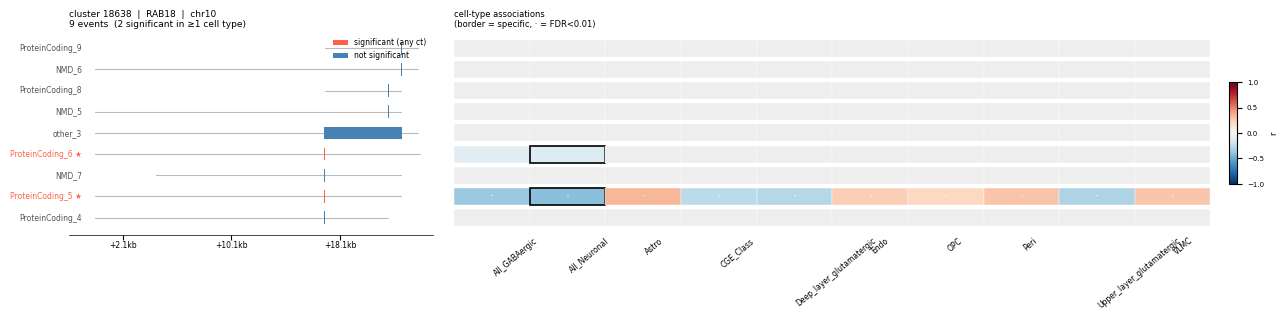

19294


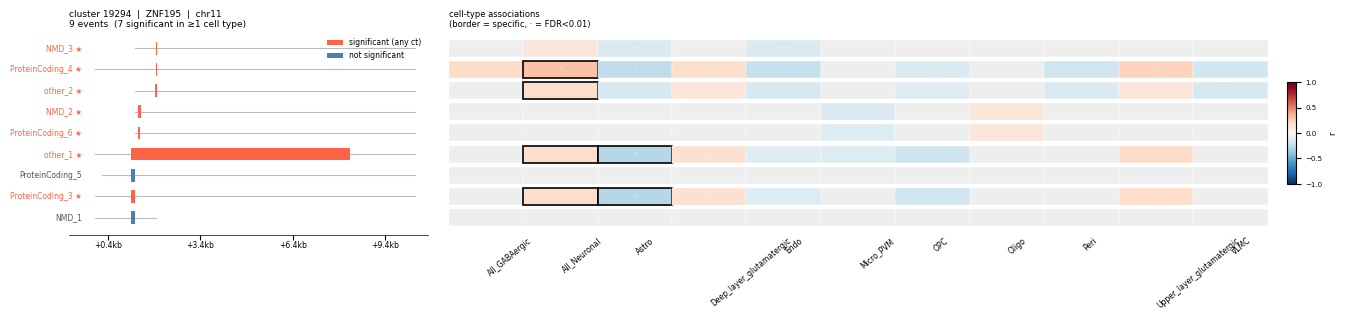

26214


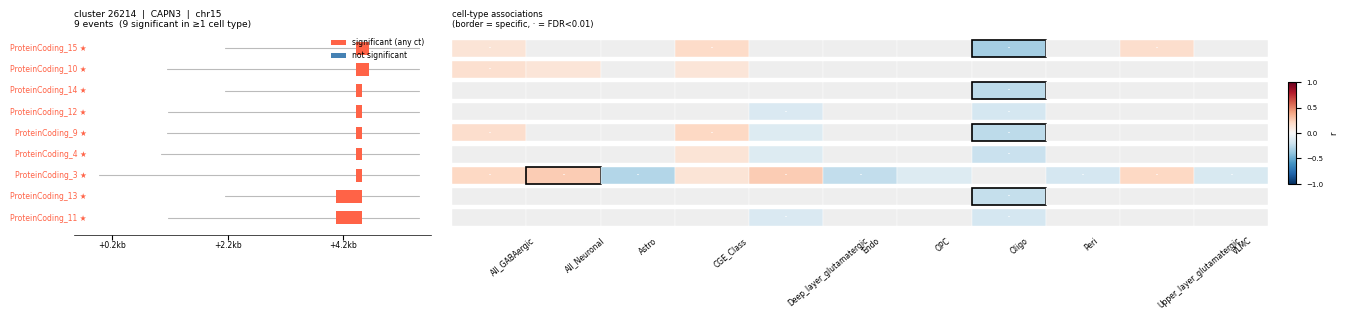

32190


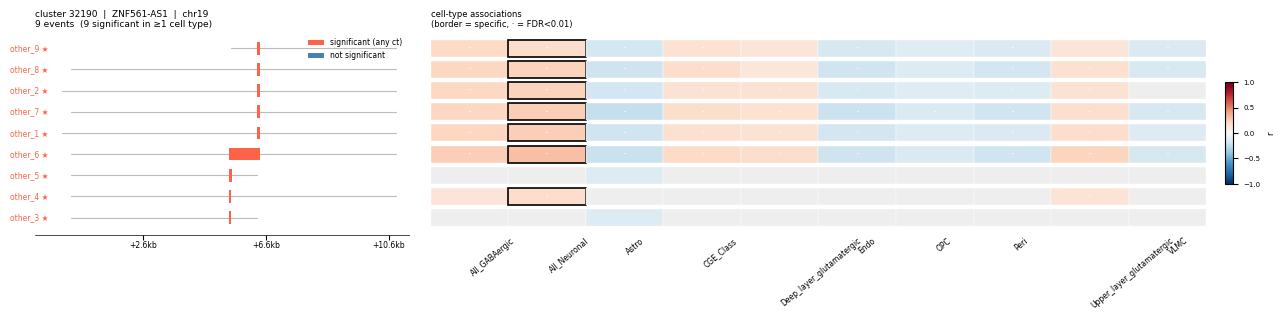

35317


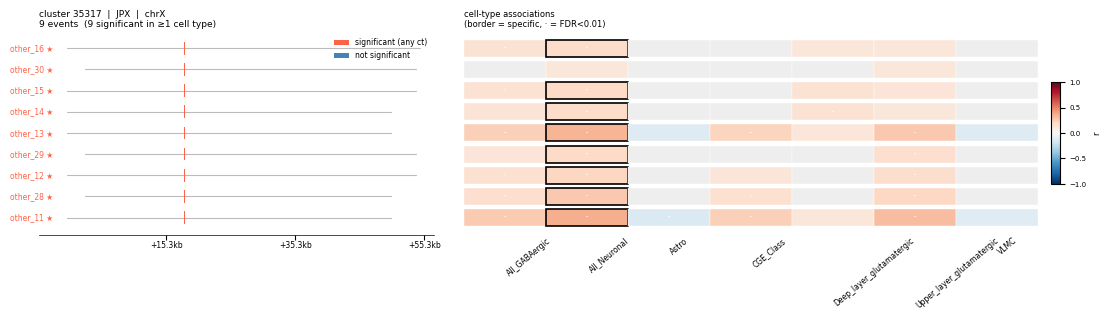

2769


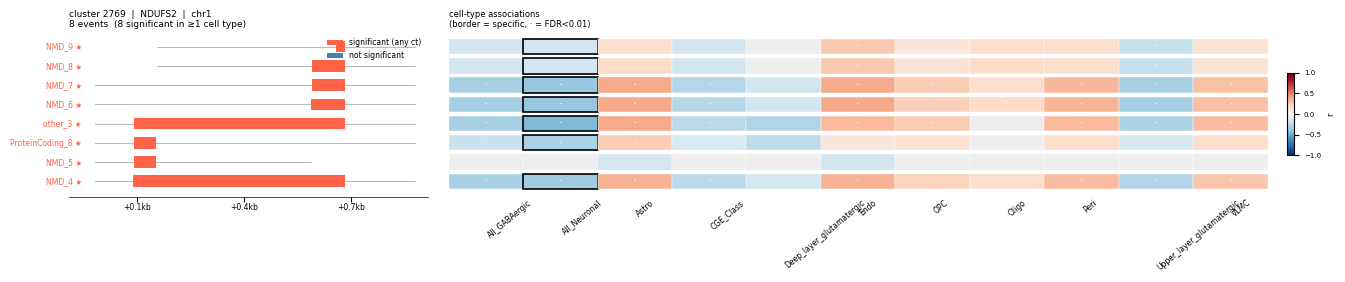

3745


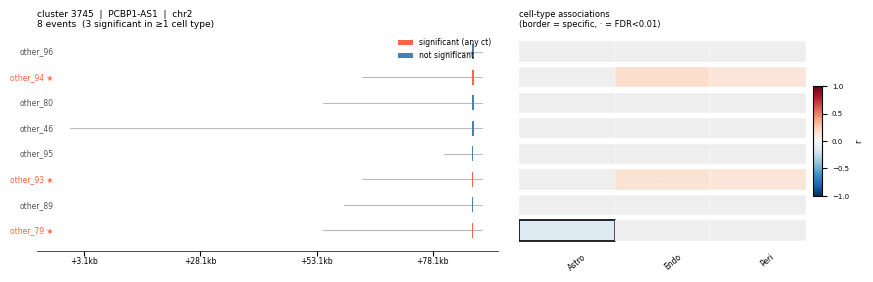

13824


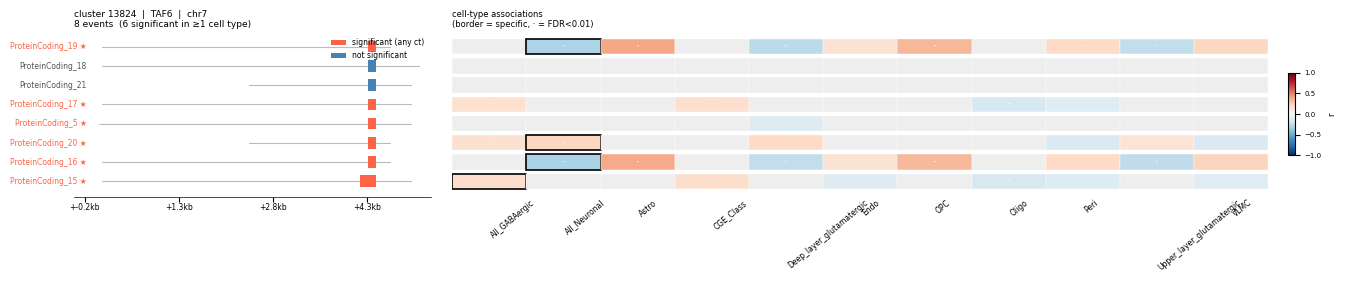

13833


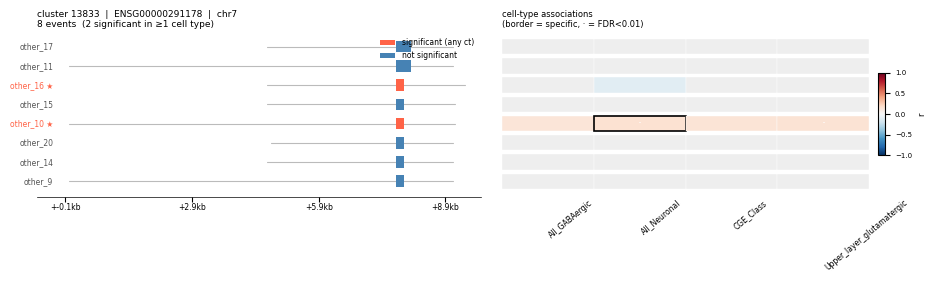

16513


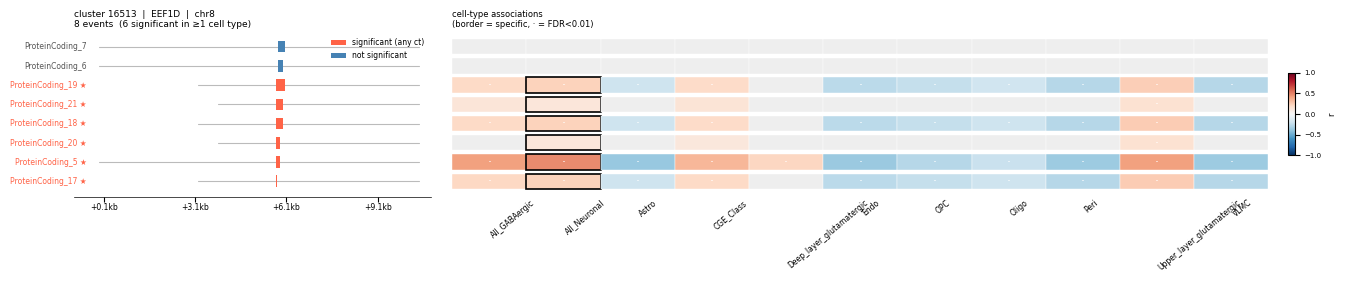

16512


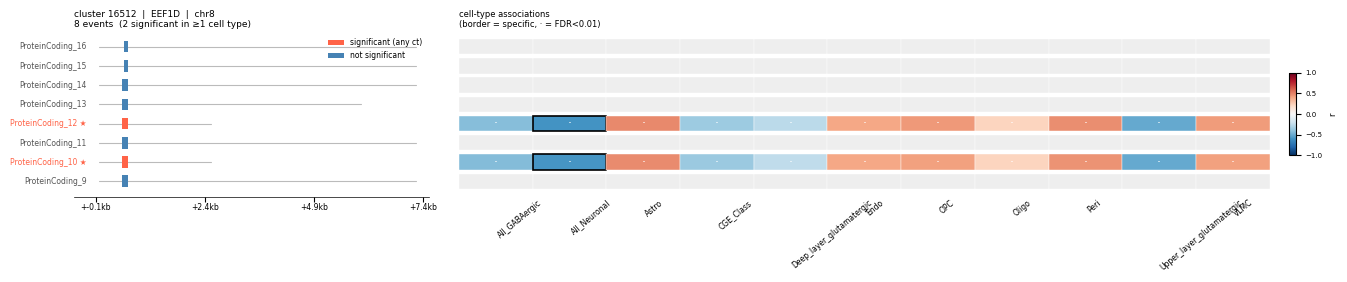

25083


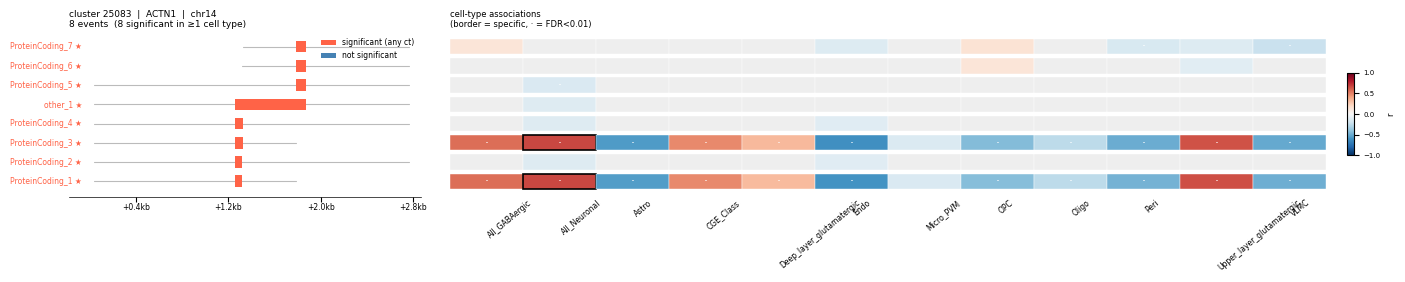

29028


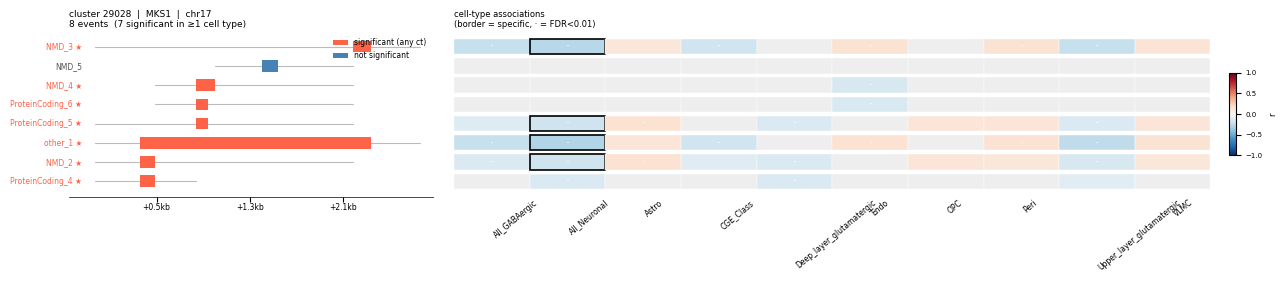

29191


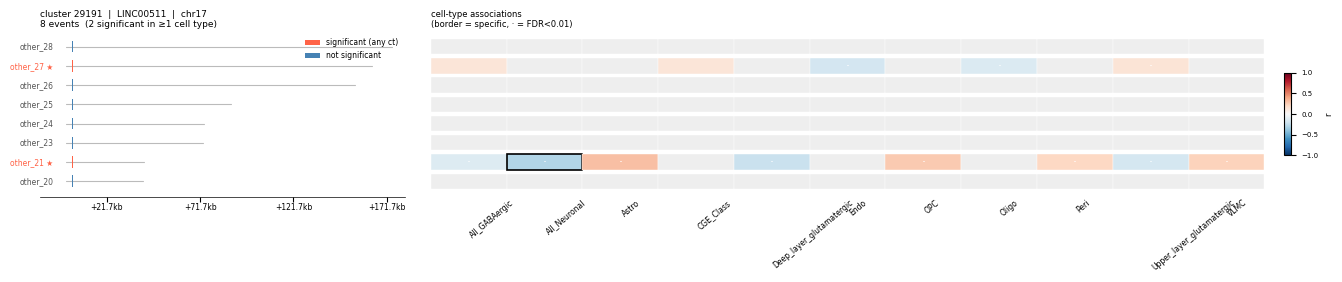

29394


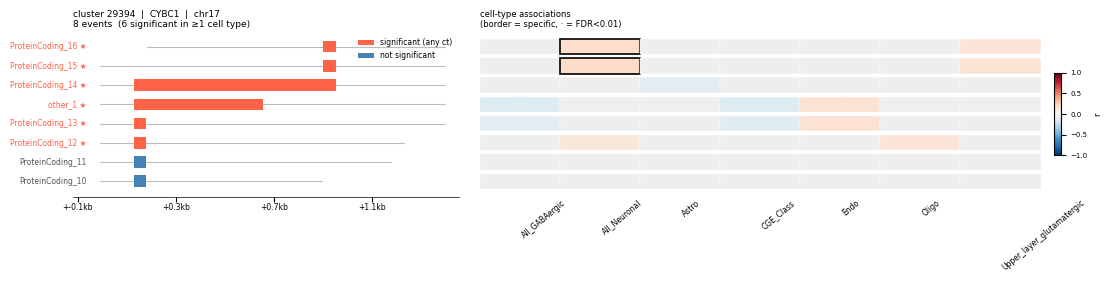

33842


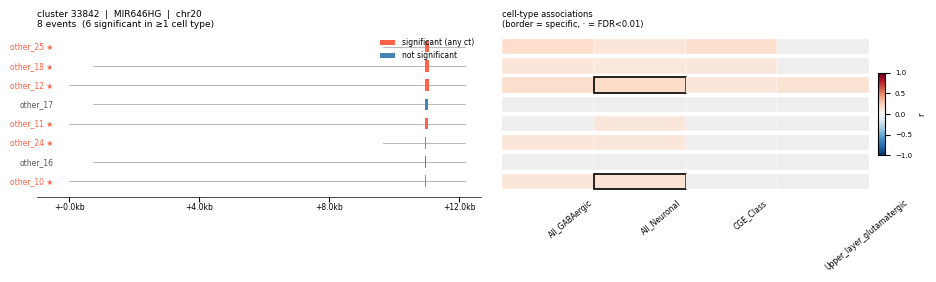

1668


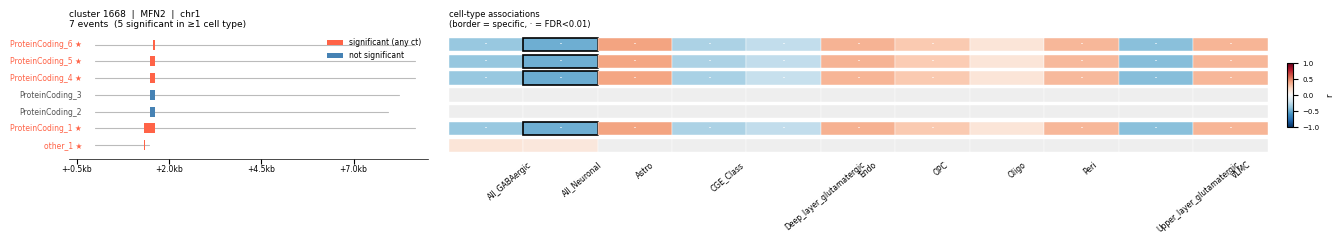

810


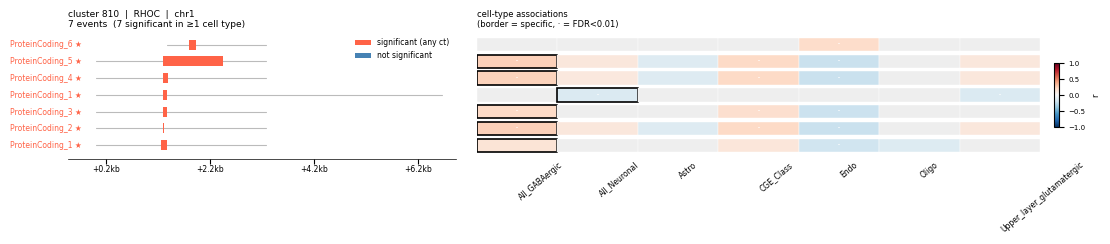

In [ ]:
import sys

# sys.path.append("~/code")

# from plot_clusters import plot_cluster

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages('all_clusters.pdf') as pdf:
    for cid in sorted_cids[:50]:
        print(cid)
        fig = plot_cluster(cid, members[cid], event_info, signif_info)
        if fig is not None:
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)

In [109]:
# bucket = event_info[ev]['compatible']
# best_t = max(bucket, key=lambda t: bucket[t]['score'])
# best_d = bucket[best_t]
# best_d

{'overlap_type': 'noncoding_or_utr',
 'transcript_type': 'lncRNA',
 'transcript_tag': 'TAGENE',
 'score': (0, 0, 0, 0, 0, 0, 0, 'ENST00000686333')}

# Ignore

In [ ]:

# event_info = {}

# # For each splicing event: save transcripts with compatible_junctions splice junctions

# for idx, val in tqdm(event_lookup.items(), total=len(event_lookup)):
#     event_info[idx] = {}
#     exon_start, exon_end, chrom = val['exon_start'], val['exon_end'], val['chr']
#     target_exon = gtf_indexed.loc[(chrom, exon_start, exon_end)]
#     strand = target_exon.strand.values[0]
    
#     event_introns = event_jxns_df[event_jxns_df.event == idx]
#     i1 = event_introns[event_introns.index.str.endswith("I1")]
#     i2 = event_introns[event_introns.index.str.endswith("I2")]
#     upstream_intron_start = i1.intron_start.values[0]
#     downstream_intron_end = i2.intron_end.values[0]

#     compatible_junctions = {}
#     incompatible_junctions = {}
    
#     # for each transcript that contains the target exon:
    
#     for _, exon_row in target_exon.iterrows():
#         target_transcript = exon_row['transcript']
#         exon_number = int(exon_row['exon_number'])
#         exon_id = exon_row['exon_id']
#         all_exons_in_transcript = exons_by_transcript.get(target_transcript)

#         classify_isoform(exons, es, ee, us_intron_start, ds_intron_end)
        
#         # get flanking exons' end and start (direction depends on sense)
#         upstream_num, downstream_num = (
#             (exon_number + 1, exon_number - 1) if strand == "-" \
#                     else (exon_number - 1, exon_number + 1)
#         ) 
#         te_indexed = all_exons_in_transcript.set_index(
#             all_exons_in_transcript['exon_number'].astype(int)
#         )
        
#         if (upstream_num not in te_indexed.index) or (downstream_num not in te_indexed.index):
#             continue        # exon is the first/last exon in this particular transcript (i.e. not a cassette exon)
        
#         upstream_exon_end = te_indexed.loc[upstream_num, 'end'] + 1
#         downstream_exon_start = te_indexed.loc[downstream_num, 'start'] - 1

#         transcript_dict_val = {
#             "strand": strand,
#             "transcript_type": all_exons_in_transcript.transcript_type.values[0], 
#             "exon_number": exon_number,
#             "exon_id": exon_id,
#             "tag": all_exons_in_transcript.tag.values[0],
#             "aa_start": '',
#             "aa_end": '',
#             "overlap_type": '',
#             "coding_nt_length": '',
#             "full_exon_nt_length": exon_end - exon_start + 1 
#         }
        
#         transcript_cds = cds_by_transcript.get(target_transcript)
        
#         if transcript_cds is None:
#             continue    # transcript is noncoding
        
        
#         overlapping_cds = find_overlapping_cds(exon_start, exon_end, transcript_cds)

#         if overlapping_cds is None:
#             continue   # exon is in UTR for this transcript
        
#         ######## if exon overlaps a coding region, get additional info #######
 

        

#         # genomic coordinates of exon portion that OVERLAPS coding sequence
#         exon_cds_start = overlapping_cds['start']
#         exon_cds_end = overlapping_cds['end']
        
#         # calc relative position of the exon CDS in working transcript CDS
#         cds_offset = 0  
#         gtf_frame = None
#         for _, cds_row in transcript_cds.iterrows():
#             if cds_row['start'] == exon_cds_start and cds_row['end'] == exon_cds_end:
#                 gtf_frame = int(cds_row['frame'])
#                 break   # reached our exon, stop
#             cds_offset += cds_row['end'] - cds_row['start'] + 1
        
#         # exon position relative to beginning of coding region
#         # note: these coordinates describe the CODING PORTION of the exon
#         rel_exon_start = cds_offset
#         rel_exon_end = cds_offset + (exon_cds_end - exon_cds_start)

#         # (first_frame - rel_exon_start): how many nts does the coding region UP TO target exon have (after accounting for incomplete upstream CDS)?
#                                             # note: a first frame != 0 should only happen for transcripts with incomplete 5' annotations
#         # (above) % 3: e.g. if above is divisble by 3, this should return frame 0
#         first_frame = int(transcript_cds.iloc[0].frame) 
#         this_cds_frame = (first_frame - rel_exon_start) % 3
#         assert this_cds_frame == gtf_frame, (
#             f"frame mismatch {target_transcript}: computed {this_cds_frame}, GTF {gtf_frame}"
#         )
        
#         aa_start = rel_exon_start // 3
#         aa_end = rel_exon_end // 3

#         coding_nt_length = exon_cds_end - exon_cds_start + 1
#         clean_start = (gtf_frame == 0)
#         clean_end = ((coding_nt_length - gtf_frame) % 3 == 0)
#         frame_preserving = (coding_nt_length % 3 == 0)
        
#         # get position of amino acids encoded by the target exon
#         transcript_dict_val.update({
#             "aa_start": aa_start,
#             "aa_end": aa_end,
#             "overlap_type": classify_overlap(exon_start, exon_end, overlapping_cds),
#             "coding_nt_length": coding_nt_length,
#             "frame_preserving": frame_preserving,
#             "clean_start": clean_start,
#             "clean_end": clean_end
#         })
       
#         # stratify based on matching splice junctions: 
#         if (upstream_intron_start == upstream_exon_end) and (downstream_intron_end == downstream_exon_start):
#             compatible_junctions[target_transcript] = transcript_dict_val 
#         else:
#             incompatible_junctions[target_transcript] = transcript_dict_val

#     event_info[idx]["compatible_junctions"] = compatible_junctions
#     event_info[idx]["incompatible_junctions"] = incompatible_junctions 

In [ ]:
# rows = []
# for idx, transcripts in event_info.items():
#     for transcript, compatability in transcripts.items(): 
#         for compatability, info in transcripts.items():
#             rows.append({
#                 'event': idx,
#                 'compatability': compatability,
#                 'transcript': transcript,
#                 'transcript_type': info['transcript_type'],
#                 'exon_number': info['exon_number'],
#                 'tag': info['tag'],
#                 'aa_start': info['aa_start'],
#                 'aa_end': info['aa_end'],
#                 'overlap_type': info['overlap_type'],
#                 'coding_nt_length': info['coding_nt_length'],
#                 'full_exon_nt_length': info['full_exon_nt_length']
#             })

# event_info_df = pd.DataFrame(rows).set_index('event')

## Log which transcripts were detected in RNA-seq data

In [ ]:
rsem_expr = pd.read_csv("/mnt/lareaulab/reliscu/projects/NSF_GRFP/data/bulk/GTEx/cortex/GTEx_cortex_RSEM_TPM.csv", index_col=0)
rsem_expr_subset = rsem_expr[rsem_expr.index.isin(event_info_df['transcript'])]

### Calc isoform vs. ME corr

In [24]:
ctype_abund_df = pd.read_csv("data/ctype_abundance/GTEx_cortex_counts_TMMF_All_501_outliers_removed_top_Qval_mods_PC1_ctype_abundance_filtered_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules_top_corr_enriched_w_Claude_marker_genes_PC1_ctype_abundance.csv", index_col=0)
ctype_abund_df.index = ctype_abund_df.index.str.replace(".", "-")

In [25]:
rsem_corr_results = {}
for ct in ctype_abund_df.columns:
    print(ct)
    rsem_corr_results[ct] = rsem_expr_subset.T.corrwith(ctype_abund_df[ct])

CGE Class
All GABAergic
Deep layer glutamatergic
All Neuronal
Oligo
Endo
Peri
OPC
Astro
Micro/PVM
VLMC
Upper layer glutamatergic


In [ ]:
rsem_corr_df = pd.DataFrame(rsem_corr_results)
rsem_corr_df.to_csv(f"data/corrs/GTEx_RSEM_TPM_ctype_abundance_corr.csv")

### Also save isoform mean expression

In [ ]:
rsem_mean_expr = rsem_expr_subset.iloc[:, 1:].mean(axis=1)
is_detected = rsem_mean_expr.index.isin(event_info_df.transcript)

In [28]:
rsem_info_df = pd.DataFrame({'RSEM_detected': is_detected, 'RSEM_mean_expr': rsem_mean_expr}, index=rsem_mean_expr.index)

## Now append exon info. to cell type exon analysis results

In [29]:
pd.set_option('display.max_columns', None)

In [30]:
column_order = ['Gene', 'is_specific', 'specific_direction', 
                'chr', 'strand', 'exon_start', 'exon_end', 'exon_len', 'transcript', 'transcript_type', 
                'exon_number', 'tag', 'coding_nt_length', 'full_exon_nt_length', 'overlap_type',  
                'aa_start', 'aa_end', 'RSEM_detected', 'RSEM_mean_expr', 'RSEM_expr_corr', 
                'r', 'fdr', 
                'CGE Class', 'All GABAergic', 'All Neuronal',
                'Upper layer glutamatergic', 'Deep layer glutamatergic', 'Oligo', 'OPC',
                'Astro', 'Micro/PVM', 'VLMC', 'Endo', 'Peri'
                ]

In [31]:
rsem_corr_df.columns = rsem_corr_df.columns.str.replace("/", "_").str.replace(" ", "_")

In [ ]:
for file in os.listdir("data/ctype_exons"):
    if file.endswith("exons.csv"):
        ct = file.split("_exons.csv")[0]
        print(ct)
        
        signif_exons_df = pd.read_csv(f"data/ctype_exons/{file}", index_col=0)
        
        ctype_corr = rsem_corr_df[ct]
        ctype_corr.name = "RSEM_expr_corr"
        rsem_corr_info_df = rsem_info_df.merge(
            ctype_corr, left_index=True, right_index=True
        )
        exon_rsem_info_df = event_info_df.merge(
            rsem_corr_info_df, left_on="transcript", right_index=True, how="left"
        )
        mask = exon_rsem_info_df.RSEM_detected == True 
        exon_rsem_info_df.loc[~mask, 'RSEM_detected'] = False
        
        signif_exons_info = signif_exons_df.merge(
            exon_rsem_info_df, 
            left_index=True, 
            right_index=True,
            how='left'
        )
        rest_columns = signif_exons_info.columns[signif_exons_info.columns.str.contains("diff")].tolist() 
        new_file = file.replace('_exons.csv', '_exons_annotated.csv')
        signif_exons_info[column_order + rest_columns].to_csv(f"data/ctype_exons/annotated/{new_file}")

Oligo
VLMC
Endo
Deep_layer_glutamatergic
Astro
OPC
Micro_PVM
All_Neuronal
All_GABAergic
Peri
CGE_Class
Upper_layer_glutamatergic


In [41]:
pd.set_option('display.max_columns', None)